In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
cpi_test = pd.read_csv('CPI_test.csv')
our_forecast = pd.read_csv('Group_41_forecast.csv')
test_error = mean_squared_error(cpi_test['CPI'], our_forecast['CPI'])
print(test_error)

1977.9572417324064


**1. Impot Required Library**

In [2]:
import pandas as pd
import numpy as np
import time
import seaborn as sns
from datetime import datetime
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels as sm
import statsmodels.api as smt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import LSTM

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import warnings
warnings.filterwarnings("ignore")
# Authenticate and create the PyDrive client.
# This only needs to be done once per notebook.

# auth.authenticate_user()
# gauth = GoogleAuth()
# gauth.credentials = GoogleCredentials.get_application_default()
# drive = GoogleDrive(gauth)

# #https://drive.google.com/file/d/1xr8ZhnQpoVySvlFnse9g1abphLHmJeUW/view?usp=sharing
# file_id = '1xr8ZhnQpoVySvlFnse9g1abphLHmJeUW' # URL id. 
# downloaded = drive.CreateFile({'id': file_id})
# downloaded.GetContentFile('CPI_test.csv')

# #https://drive.google.com/file/d/1VCcnnryk2_-sKG4CwxYuo_Nhol7eXhmD/view?usp=sharing
# file_id = '1VCcnnryk2_-sKG4CwxYuo_Nhol7eXhmD' # URL id. 
# downloaded = drive.CreateFile({'id': file_id})
# downloaded.GetContentFile('CPI_train.csv')

In [3]:
# print(tf.__version__)
# import keras
# print(keras.__version__)

**2. Helper Functions**

In [4]:
# Calculate MSE function
def calculate_mse(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    return mse

# H0: the time series is non-stationary
# Test statistics less than critical value, reject H0
def test_stationarity(timeseries, showprint = True):
    # Perform Dickey-Fuller test:
    #print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    
    # Print test outputs
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','pvalue','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    if showprint == False:
      return dfoutput
    else:
      print(dfoutput)

# Plot function
def plot_curve(timeseries):
    # Determing rolling statistics
    rolmean = timeseries.rolling(4,center=True).mean()
    rolstd = timeseries.rolling(4,center=True).std()

    # Plot rolling statistics:
    plt.figure(figsize=(15,6))
    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()

# print outcome of dickey fuller test
def print_outcome(result):
  test_stat = result['Test Statistic']
  crit_1 = result['Critical Value (1%)']
  crit_5 = result['Critical Value (5%)']
  crit_10 = result['Critical Value (10%)']
  if test_stat < crit_1:
    print('Reject HO at 1% level')
  else:
    print('Do not reject HO at 1% level')

  if test_stat < crit_5:
    print('Reject HO at 5% level')
  else:
    print('Do not reject HO at 5% level')

  if test_stat < crit_10:
    print('Reject HO at 10% level')
  else:
    print('Do not reject HO at 10% level')

**3. Load data**

In [5]:
# Global parameter setup
np.random.seed(6840)

# Import data
train_data = pd.read_csv('CPI_train.csv')

# Indexing by time
train_data['Quarter']=pd.to_datetime(train_data['Quarter'])
train_data.set_index('Quarter', inplace=True)

# Extract CPI column
cpi_train = train_data['CPI']
cpi_train_full = train_data['CPI'].copy() # make a copy of original train.csv before train/test split

#roughly 80% of train set, 20% of test set
cpi_test = cpi_train[-24:] 
cpi_train = cpi_train[:-24]

In [6]:
cpi_train_full

Quarter
1990-03-01     43.513571
1990-06-01     43.993571
1990-09-01     44.593571
1990-12-01     46.633571
1991-03-01     48.673571
                 ...    
2019-12-01    165.313571
2020-03-01    168.073571
2020-06-01    167.713571
2020-09-01    167.473571
2020-12-01    169.633571
Name: CPI, Length: 124, dtype: float64

## **Exploratory data analysis**

In [7]:
# Extract CPI column
cpi_series = train_data['CPI']

In [8]:
#check missing value
print(train_data.isnull().sum())

CPI    0
dtype: int64


In [9]:
cpi_series.head()

Quarter
1990-03-01    43.513571
1990-06-01    43.993571
1990-09-01    44.593571
1990-12-01    46.633571
1991-03-01    48.673571
Name: CPI, dtype: float64

In [10]:
train_data.describe().round(4)

,CPI
count,124.0000
mean,97.9974
std,37.2322
min,43.5136
25%,67.1236
50%,89.2336
75%,129.4036
max,169.6336


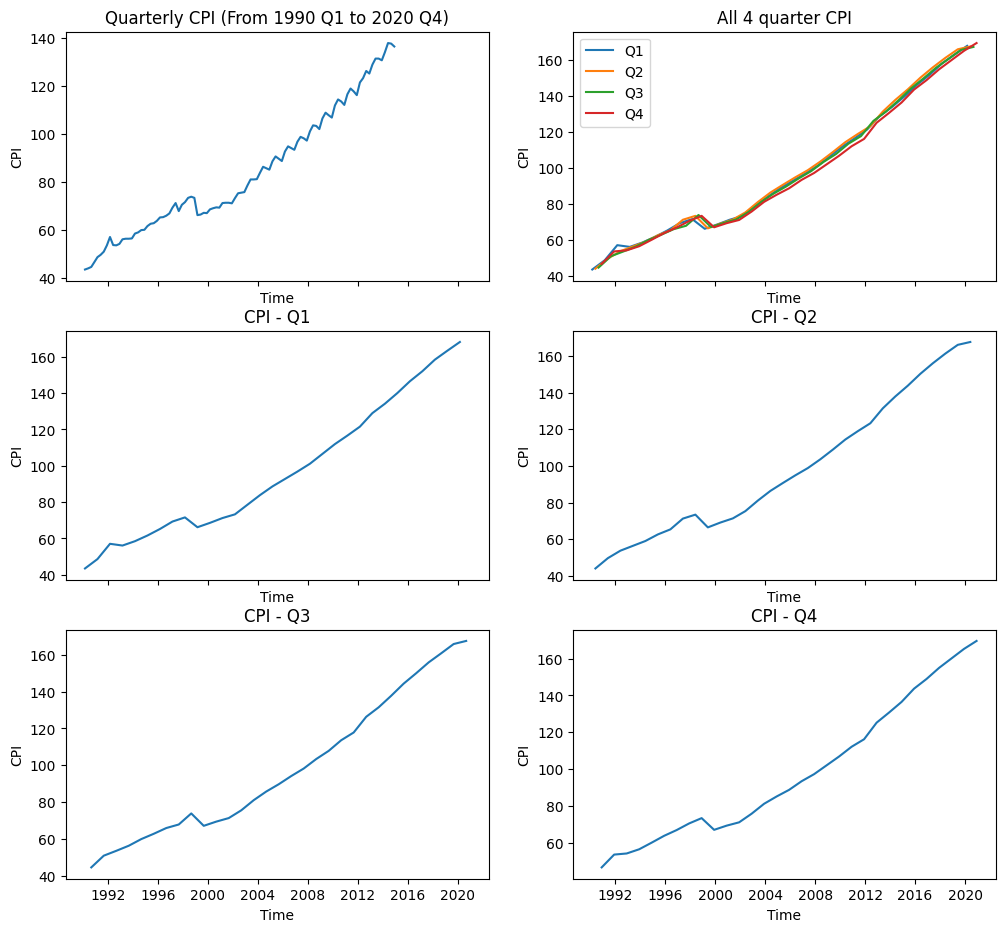

In [11]:
# Define the quarter months
months = [3, 6, 9, 12]

# Plot CPI
fig, ax = plt.subplots(3, 2, sharex=True, figsize=(12, 11))

ax[0,0].plot(cpi_train)
ax[0,0].set_title('Quarterly CPI (From 1990 Q1 to 2020 Q4)')
ax[0,0].set_xlabel('Time')
ax[0,0].set_ylabel('CPI')

# Iterate over the quarter months and plot the corresponding time series data
for i, month in enumerate(months):
    cpi_Q = cpi_series[cpi_series.index.month == month]
    row = i // 2 + 1
    col = i % 2
    ax[row, col].plot(cpi_Q)
    ax[row, col].set_title(f'CPI - Q{i+1}')
    ax[row, col].set_xlabel('Time')
    ax[row, col].set_ylabel('CPI')
    ax[0,1].plot(cpi_Q, label=f'Q{i+1}')
    ax[0,1].set_title('All 4 quarter CPI')
    ax[0,1].set_xlabel('Time')
    ax[0,1].set_ylabel('CPI')
    ax[0,1].legend()

plt.show()

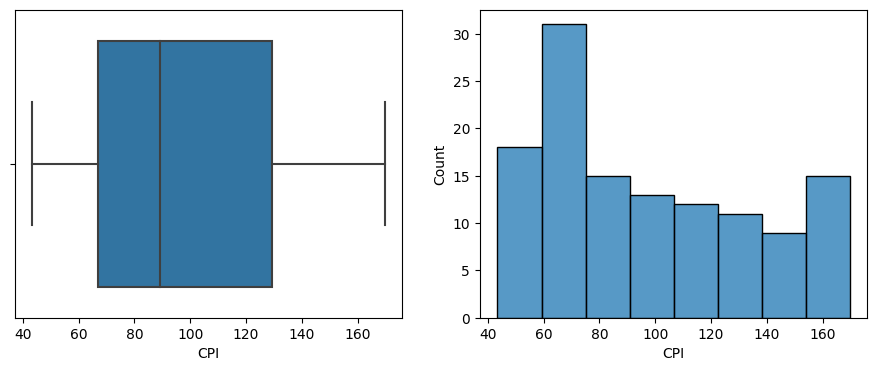

In [12]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Boxplot
sns.boxplot(x=cpi_series, ax=axes[0])
# Distribution plot
sns.histplot(train_data['CPI'], ax=axes[1])
plt.show()

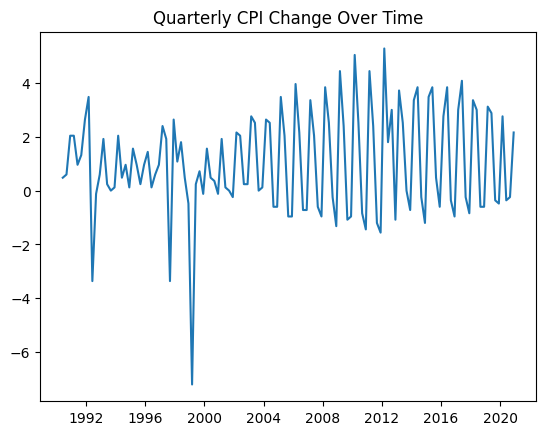

In [13]:
plt.plot(pd.Series.diff(cpi_series))
plt.title('Quarterly CPI Change Over Time')
plt.show()

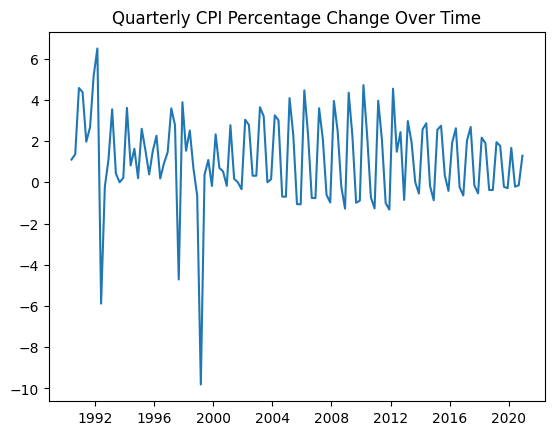

In [14]:
plt.plot(cpi_series.pct_change() * 100)
plt.title('Quarterly CPI Percentage Change Over Time')
plt.show()

# **Linear Regression**

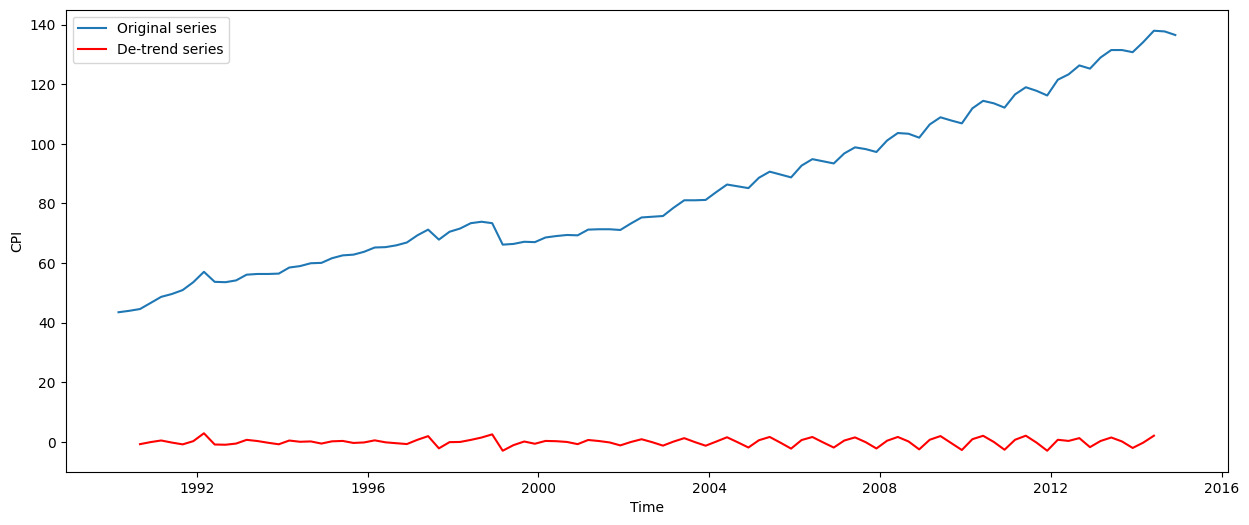

In [15]:
# Apply CMA-M with M=4 to initially estimate the trend
# Shift the new series to equalize (symmetrize) the number of missing values on both sides
Trend_init = cpi_train.rolling(4,center=True).mean().rolling(2,center=True).mean().shift(-1)

# Subtract the initial trend from the original series to obtaibed the de-trend series
ts_res = cpi_train - Trend_init

# Plot the de-trended and original series
plt.figure(figsize = (15,6))
plt.plot(cpi_train.index,cpi_train,label="Original series")
plt.plot(cpi_train.index,ts_res,'r-',label="De-trend series")
plt.xlabel('Time')
plt.ylabel('CPI')
plt.legend()
plt.show()

In [16]:
# Replace missing values in the ts_res by zeros
ts_res_zero = np.nan_to_num(ts_res)

# Reshape the de-trended series to a table. 
# A column contains data in a particular quarter of 25 years.
# For example, column 1 contains number of passengers in January of 25 years.
quarterly_S = np.reshape(ts_res_zero, (25,4))

# Calculate column averages (Average number of passengers in 4 quarters of 25 years)
quarterly_avg = np.mean(quarterly_S[1:24,:], axis=0)

In [17]:
quarterly_avg

array([ 0.43173913,  0.86934783, -0.13043478, -1.2       ])

In [18]:
# Normalize the seasonal index
seasonal_idx = quarterly_avg.mean()
seasonal_idx_normalized = quarterly_avg - seasonal_idx
print(seasonal_idx_normalized.mean())

0.0


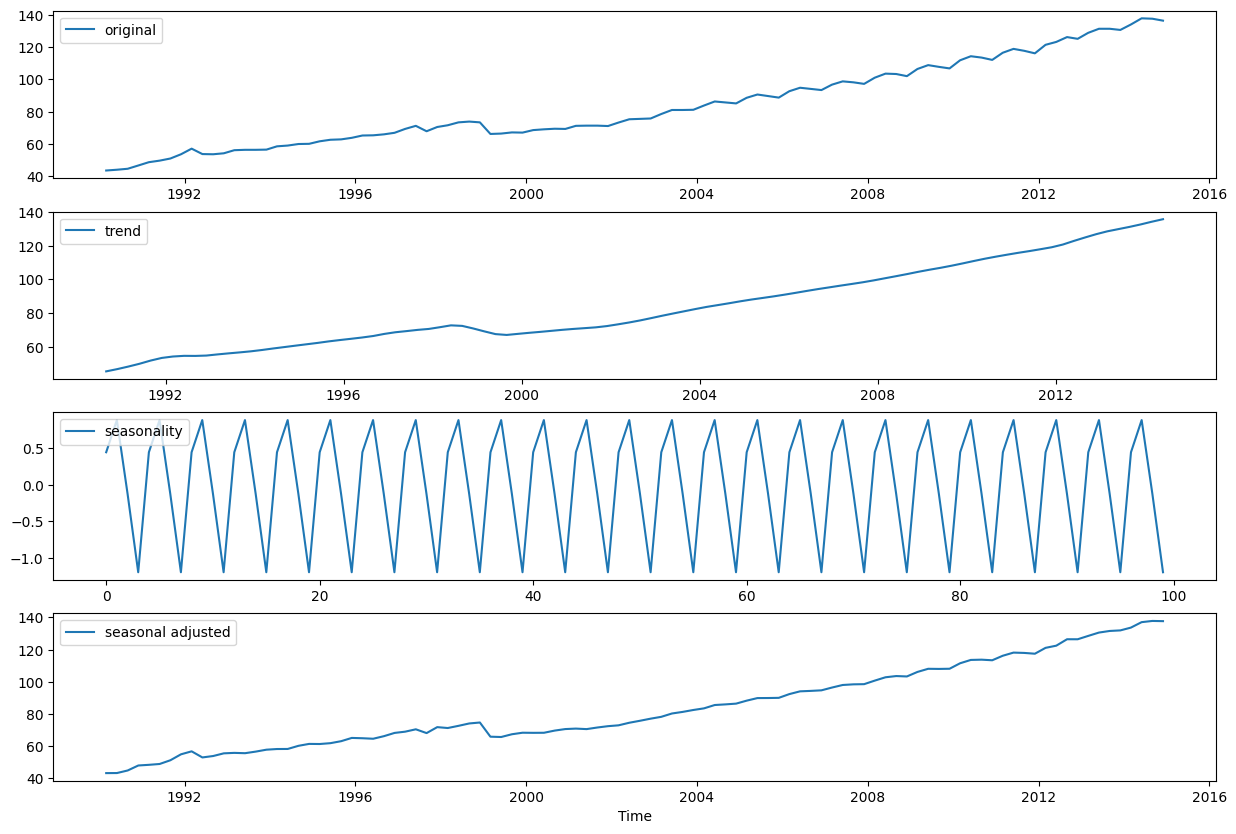

In [19]:
# Replicate the normalized seasonal index array 25 times to obtain the final estimation of the seasonal component
seasonal = np.tile(seasonal_idx_normalized, 25)

# Subtract the seasonal average from the original data to obtain the seasonal adjusted data
seasonally_adjusted = cpi_train - seasonal

# Plot the seasonally adjusted data:
fig, ax = plt.subplots(4, 1,figsize=(15,10))
ax[0].plot(cpi_train)
ax[1].plot(Trend_init)
ax[2].plot(seasonal)
ax[3].plot(seasonally_adjusted)
ax[0].legend(['original'], loc=2)
ax[1].legend(['trend'], loc=2)
ax[2].legend(['seasonality'], loc=2)
ax[3].legend(['seasonal adjusted'], loc=2)
plt.xlabel('Time')
plt.show()

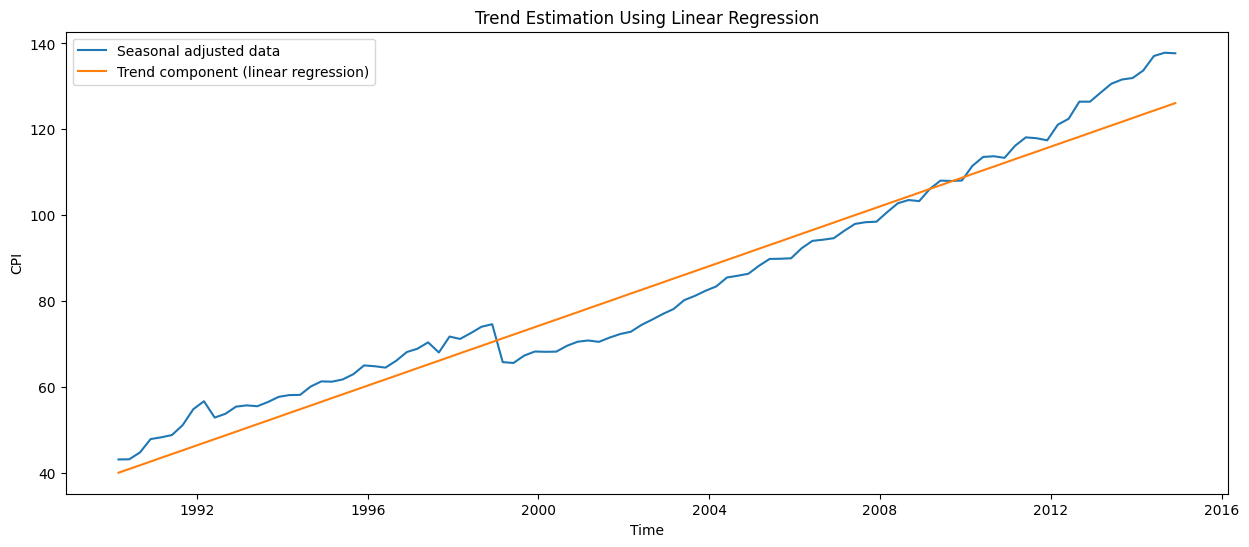

In [20]:
# Prepare training data
X = np.linspace(1, len(seasonally_adjusted), len(seasonally_adjusted)) # Create time indexes from 1 to T as the input
X = np.reshape(X, (len(seasonally_adjusted), 1))                       # Transform X to 2D array (matrix)
y = seasonally_adjusted.values    

# Create a LinearRegression object
lm = LinearRegression()   

# Train the linear regression model on training data (X,y)
lm.fit(X, y)

# Obtain estimation for the trend using the trained linear model
X_fitting = np.reshape(np.arange(len(seasonally_adjusted)), (len(seasonally_adjusted),1))
trend_linear = lm.predict(X_fitting)

# Now plot the seasonally adjusted data and the corresponding regression line
plt.figure(figsize=(15,6))
plt.plot(cpi_train.index,seasonally_adjusted)
plt.plot(cpi_train.index,trend_linear)
#plt.plot(cpi_train.index,cpi_train)
plt.title('Trend Estimation Using Linear Regression')
plt.xlabel('Time')
plt.ylabel('CPI')
plt.legend(['Seasonal adjusted data','Trend component (linear regression)'])
plt.show()

In [21]:
Trend_forecast = []
Trend_fit = []
for i in range(24):
  Trend_forecast.append(lm.predict(np.array([[len(cpi_train)+i+1]])))
for i in range(len(cpi_train)):
  Trend_fit.append(lm.predict(np.array([[i+1]])))

out = []
out_fit = []
for i in range(24):
    index2 = i % 4 
    sum_value = Trend_forecast[i] + seasonal_idx_normalized[index2]
    out.append(sum_value)

for i in range(len(cpi_train)):
    index2 = i % 4 
    sum_value = Trend_fit[i] + seasonal_idx_normalized[index2]
    out_fit.append(sum_value)

test_pred = []
for i in range(24):
  test_pred.append(out[i][0])

train_pred = []
for i in range(len(cpi_train)):
  train_pred.append(out_fit[i][0])

In [22]:
train_mse = calculate_mse(cpi_train, train_pred)
print('In sample MSE is : {:.4f}'.format(train_mse))

In sample MSE is : 31.1500


In [23]:
test_pred_df = pd.DataFrame({'time': cpi_test.index, 'CPI': test_pred})
test_pred_df.set_index("time", inplace = True)
train_pred_df = pd.DataFrame({'time': cpi_train.index, 'CPI': train_pred})
train_pred_df.set_index("time", inplace = True)

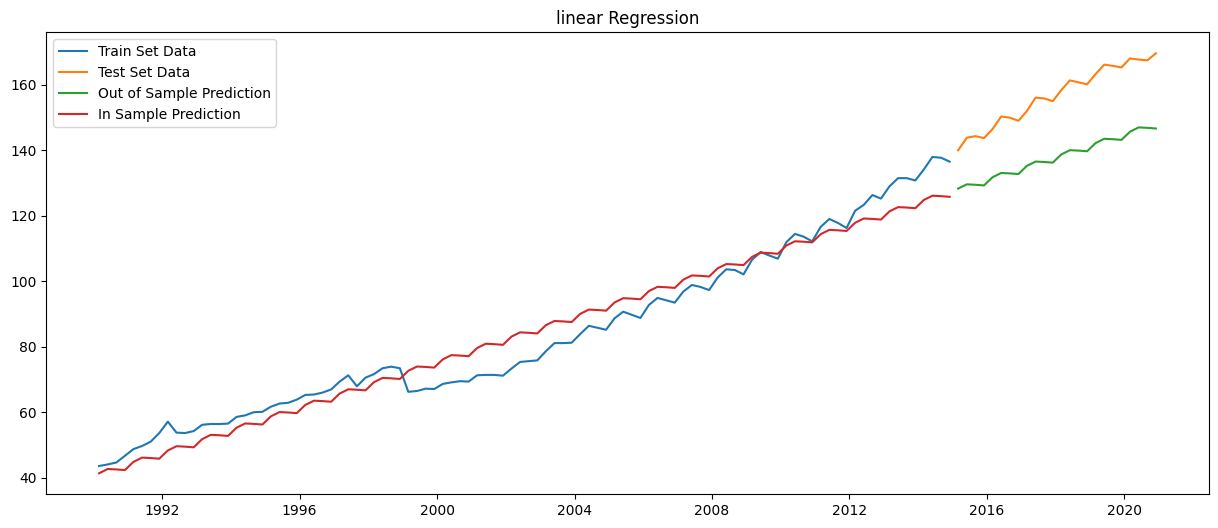

MSE for the Forecast on Test Set is 365.0345


In [24]:
# Plot forecast and test values
plt.figure(figsize=(15,6))
plt.plot(cpi_train, label='Train Set Data')
plt.plot(cpi_test, label='Test Set Data')
plt.plot(test_pred_df, label='Out of Sample Prediction')
plt.plot(train_pred_df, label='In Sample Prediction')
plt.legend(loc = "upper left")
plt.title("linear Regression")
plt.show()
# Compute MSE on Test set
print('MSE for the Forecast on Test Set is {:.4f}'.format(calculate_mse(test_pred, cpi_test)))

# **Simple Exponential Smoothing**

In [25]:
lt_pandas1 = cpi_train.ewm(alpha=0.05, adjust=False).mean()
lt_pandas2 = cpi_train.ewm(alpha=0.1, adjust=False).mean()
lt_pandas3 = cpi_train.ewm(alpha=0.3, adjust=False).mean()
lt_pandas4 = cpi_train.ewm(alpha=0.7, adjust=False).mean()
lt_pandas5 = cpi_train.ewm(alpha=1, adjust=False).mean()

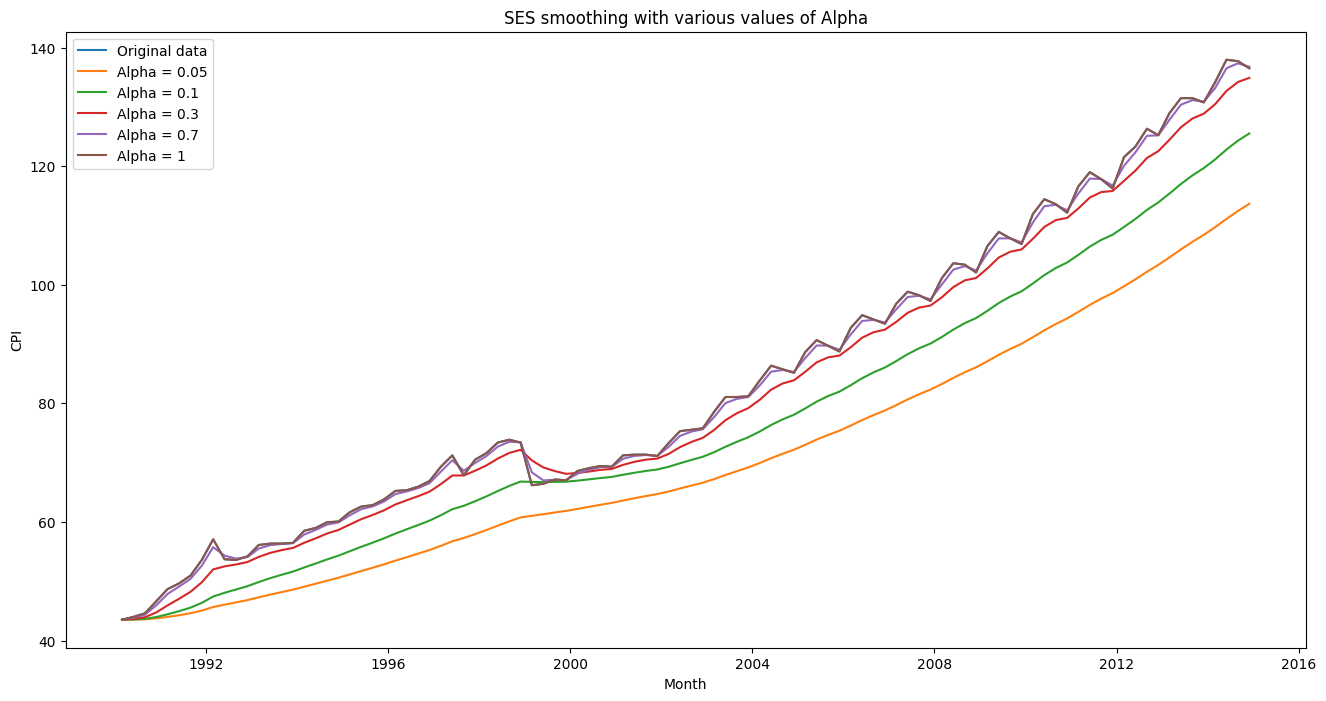

In [26]:
plt.figure(figsize=(16,8))
plt.plot(cpi_train, label='Original data')
plt.plot(lt_pandas1, label = "Alpha = 0.05")
plt.plot(lt_pandas2, label = "Alpha = 0.1")
plt.plot(lt_pandas3, label = "Alpha = 0.3")
plt.plot(lt_pandas4, label = "Alpha = 0.7")
plt.plot(lt_pandas5, label = "Alpha = 1")
plt.xlabel('Month')
plt.ylabel('CPI')
plt.title("SES smoothing with various values of Alpha")
plt.legend()
plt.show()

In [27]:
#get train MSE
alphas = np.arange(0.01, 1.01, 0.01)

#choose optimal solution for alpha based on test mse
mse_ls = []
for alpha in alphas:
  SES_model = SimpleExpSmoothing(cpi_train).fit(smoothing_level=alpha)
  test_pred = SES_model.forecast(24)
  mse_ls.append(calculate_mse(test_pred, cpi_test))

optimal_alpha_one = alphas[np.argmin(mse_ls)]
print("Optimal Alpha is {:.2f}".format(optimal_alpha_one))

Optimal Alpha is 0.70


In [28]:
SES_model = SimpleExpSmoothing(cpi_train).fit(smoothing_level= 0.7)
train_pred = SES_model.predict(start = cpi_train.index[0], end = cpi_train.index[-1])
print('The train MSE using SES model is : {:.4f}'.format(calculate_mse(train_pred, cpi_train)))

The train MSE using SES model is : 5.4215


In [29]:
#get test MSE
SES_model = SimpleExpSmoothing(cpi_train).fit(smoothing_level=0.70)
test_pred = SES_model.forecast(24)
print("The test MSE using SES model is: {:.4f}".format(calculate_mse(test_pred, cpi_test)))

The test MSE using SES model is: 476.9152


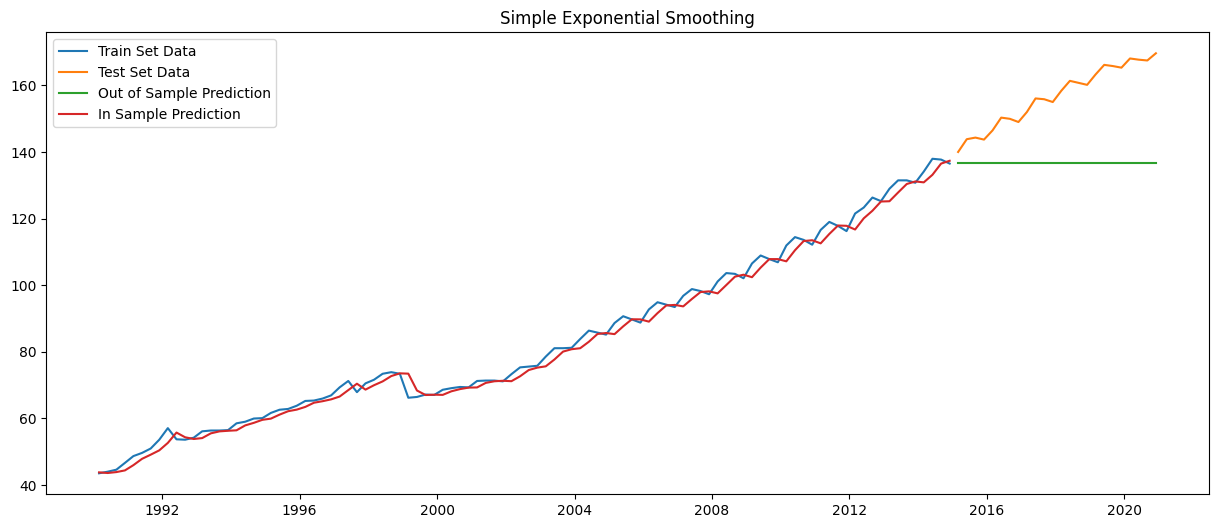

MSE for the Forecast on Test Set is 476.9152


In [30]:
test_pred_df = pd.DataFrame({'time': cpi_test.index, 'CPI': test_pred})
test_pred_df.set_index("time", inplace = True)
train_pred_df = pd.DataFrame({'time': cpi_train.index, 'CPI': train_pred})
train_pred_df.set_index("time", inplace = True)

# Plot forecast and test values
plt.figure(figsize=(15,6))
plt.plot(cpi_train, label='Train Set Data')
plt.plot(cpi_test, label='Test Set Data')
plt.plot(test_pred_df, label='Out of Sample Prediction')
plt.plot(train_pred_df, label='In Sample Prediction')
plt.legend(loc = "upper left")
plt.title("Simple Exponential Smoothing")
plt.show()
# Compute MSE on test set
print('MSE for the Forecast on Test Set is {:.4f}'.format(calculate_mse(test_pred, cpi_test)))

# **Holt-Winters smoothing**

In [31]:
fit_add = ExponentialSmoothing(cpi_train, seasonal_periods=4, trend='add', seasonal='add').fit() # Holt-Winters additive smoothing
fit_mul = ExponentialSmoothing(cpi_train, seasonal_periods=4, trend='add', seasonal='mul').fit() # Holt-Winters multiplicative smoothing

In [32]:
# symbol r $ and \ in the results variable are the latex symbols for visualization in notebook
results = pd.DataFrame(index=[r"$\alpha$",\
                              r"$\beta$",\
                              r"$\gamma$",\
                              r"$l_0$",\
                              "$b_0$",\
                              "SSE"])
# ExponentialSmoothing() object has following attributes
params = ['smoothing_level', \
          'smoothing_trend', \
          'smoothing_seasonal', \
          'initial_level', \
          'initial_trend']

# check out the performance of additive and multiplicative
results["Additive"]       = [fit_add.params[p] for p in params] + [fit_add.sse]
results["Multiplicative"] = [fit_mul.params[p] for p in params] + [fit_mul.sse]
print(results)

            Additive  Multiplicative
$\alpha$    0.833352        0.872450
$\beta$     0.047243        0.048907
$\gamma$    0.166648        0.127550
$l_0$      42.322606       44.616499
$b_0$       0.896141        0.934462
SSE       214.102332      211.566985


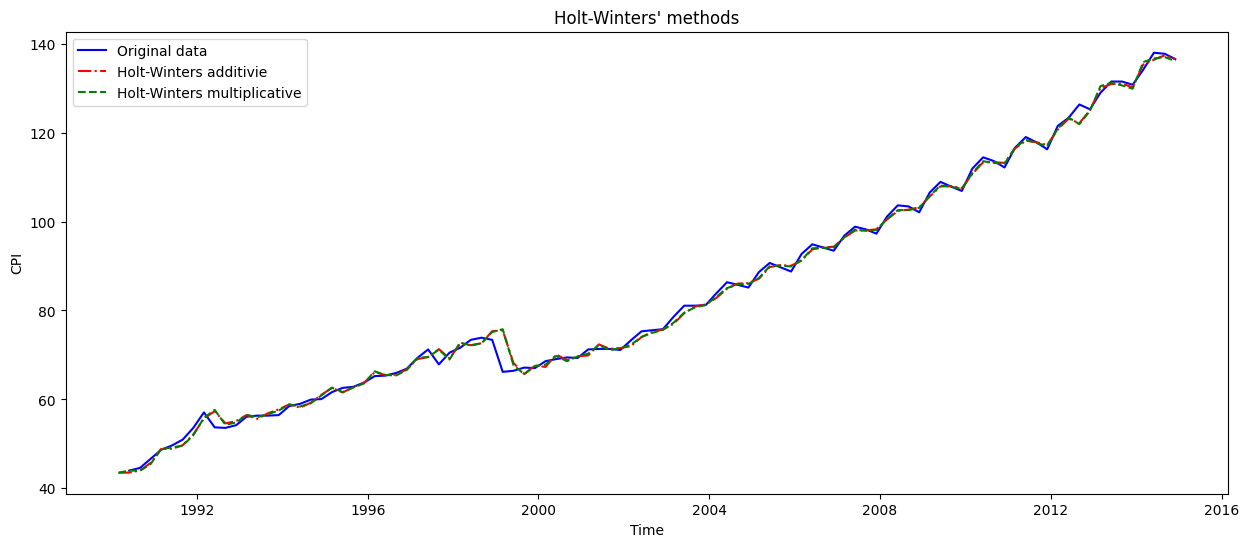

In [33]:
# Obtain fitted values from the fittedvalues attribute
smooth_add = fit_add.fittedvalues
smooth_mul = fit_mul.fittedvalues

# Plot all together
plt.figure(figsize=(15,6))
plt.plot(cpi_train[1:], 'b-', label = 'Original data')
plt.plot(smooth_add, 'r-.',label = 'Holt-Winters additivie')
plt.plot(smooth_mul, 'g--', label = 'Holt-Winters multiplicative')
plt.xlabel("Time")
plt.ylabel("CPI")
plt.title("Holt-Winters' methods")
plt.legend()
plt.show()

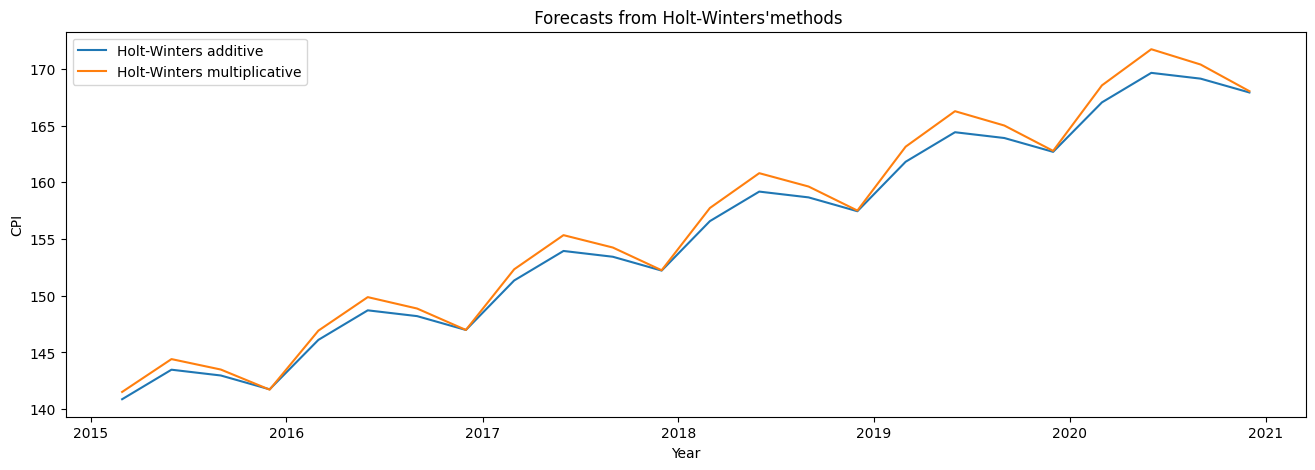

In [34]:
# Forecast 24 more data points
y_forecast_add = fit_add.forecast(24)
y_forecast_mul = fit_mul.forecast(24)

# And plot al together
plt.figure(figsize=(16,5))
plt.plot(y_forecast_add, label = 'Holt-Winters additive')
plt.plot(y_forecast_mul, label = 'Holt-Winters multiplicative')
plt.xlabel("Year")
plt.ylabel("CPI")
plt.title(" Forecasts from Holt-Winters'methods")
plt.legend()
plt.show()

In [35]:
add_model_train_pred = fit_add.predict(start = cpi_train.index[0], end = cpi_train.index[-1])
mul_model_train_pred = fit_mul.predict(start = cpi_train.index[0], end = cpi_train.index[-1])

In [36]:
add_model_train_pred

1990-03-01     43.513581
1990-06-01     43.544081
1990-09-01     43.998540
1990-12-01     45.730226
1991-03-01     48.856898
                 ...    
2013-12-01    130.157255
2014-03-01    135.280520
2014-06-01    136.378161
2014-09-01    137.371618
2014-12-01    136.492664
Freq: QS-DEC, Length: 100, dtype: float64

In [37]:
#additive model
print('The train MSE of Holt-Winters additive model is {:.4f}'.format(calculate_mse(add_model_train_pred, cpi_train)))
print('The test MSE of Holt-Winters additive model is {:.4f}'.format(calculate_mse(y_forecast_add, cpi_test)))
print()

#multiplicative model
print('The train MSE of Holt-Winters multiplicative model is {:.4f}'.format(calculate_mse(mul_model_train_pred, cpi_train)))
print('The test MSE of Holt-Winters multiplicative model is {:.4f}'.format(calculate_mse(y_forecast_mul, cpi_test)))



The train MSE of Holt-Winters additive model is 2.1410
The test MSE of Holt-Winters additive model is 3.3505

The train MSE of Holt-Winters multiplicative model is 2.1157
The test MSE of Holt-Winters multiplicative model is 2.7973


In [38]:
# Compare the forecasting outcomes of additive and multiplicative
# np.c_: Translates slice objects to concatenation along the second axis.

# For additive model
df_add = pd.DataFrame(np.c_[cpi_train, fit_add.level, fit_add.trend, fit_add.season, fit_add.fittedvalues], 
                  columns=[r'$y_t$',r'$l_t$',r'$b_t$',r'$s_t$',r'$\hat{y}_t$'],index=cpi_train.index)
df_add = df_add.append(fit_add.forecast(8).rename(r'$\hat{y}_t$').to_frame())

# For multiplicative model
df_mul = pd.DataFrame(np.c_[cpi_train, fit_mul.level, fit_mul.trend, fit_mul.season, fit_mul.fittedvalues], 
                  columns=[r'$y_t$',r'$l_t$',r'$b_t$',r'$s_t$',r'$\hat{y}_t$'],index=cpi_train.index)
df_mul = df_mul.append(fit_mul.forecast(8).rename(r'$\hat{y}_t$').to_frame())

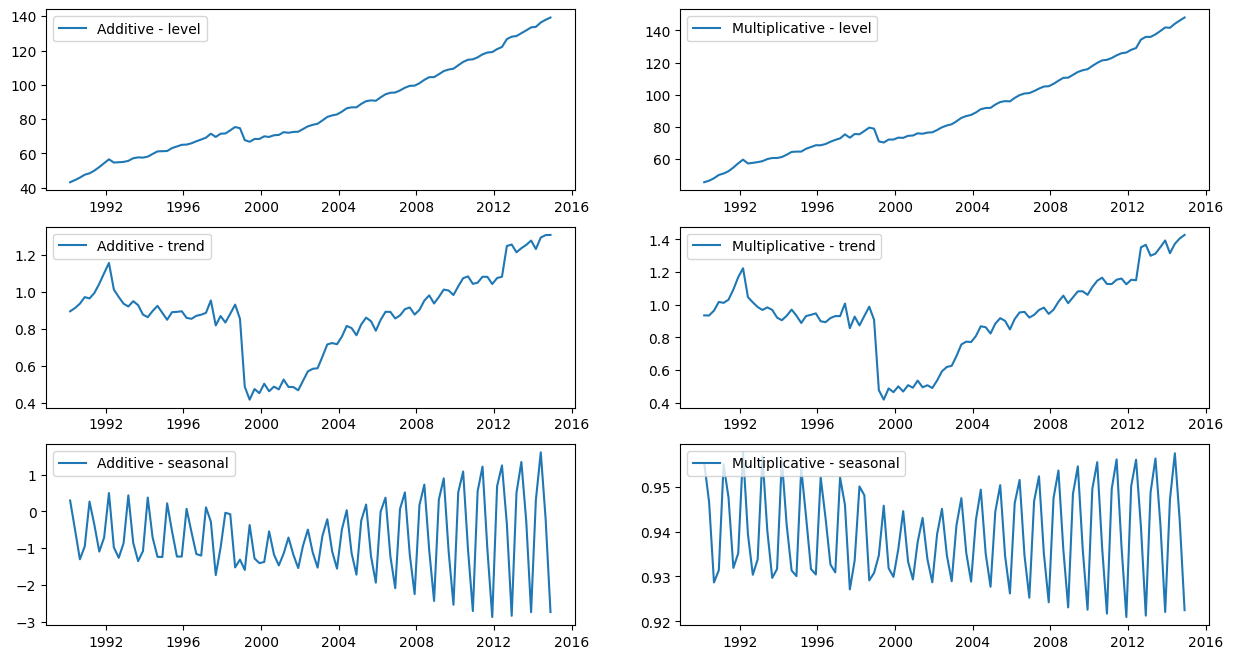

In [39]:
# Ploting the level, trend and season for fit_add and fit_mul
# Define 2 states variable for conveinence
states_add = pd.DataFrame(np.c_[fit_add.level, fit_add.trend, fit_add.season], \
                       columns=['level','trend','seasonal'], \
                       index=cpi_train.index)
states_mul = pd.DataFrame(np.c_[fit_mul.level, fit_mul.trend, fit_mul.season], \
                       columns=['level','trend','seasonal'], \
                       index=cpi_train.index)

# Define subplots windows
fig, ax = plt.subplots(3, 2, figsize=(15,8))
ax[0,0].plot(states_add['level'])
ax[1,0].plot(states_add['trend'])
ax[2,0].plot(states_add['seasonal'])
ax[0,1].plot(states_mul['level'])
ax[1,1].plot(states_mul['trend'])
ax[2,1].plot(states_mul['seasonal'])
ax[0,0].legend(['Additive - level'], loc=2)
ax[1,0].legend(['Additive - trend'], loc=2)
ax[2,0].legend(['Additive - seasonal'], loc=2)
ax[0,1].legend(['Multiplicative - level'], loc=2)
ax[1,1].legend(['Multiplicative - trend'], loc=2)
ax[2,1].legend(['Multiplicative - seasonal'], loc=2)

plt.show()

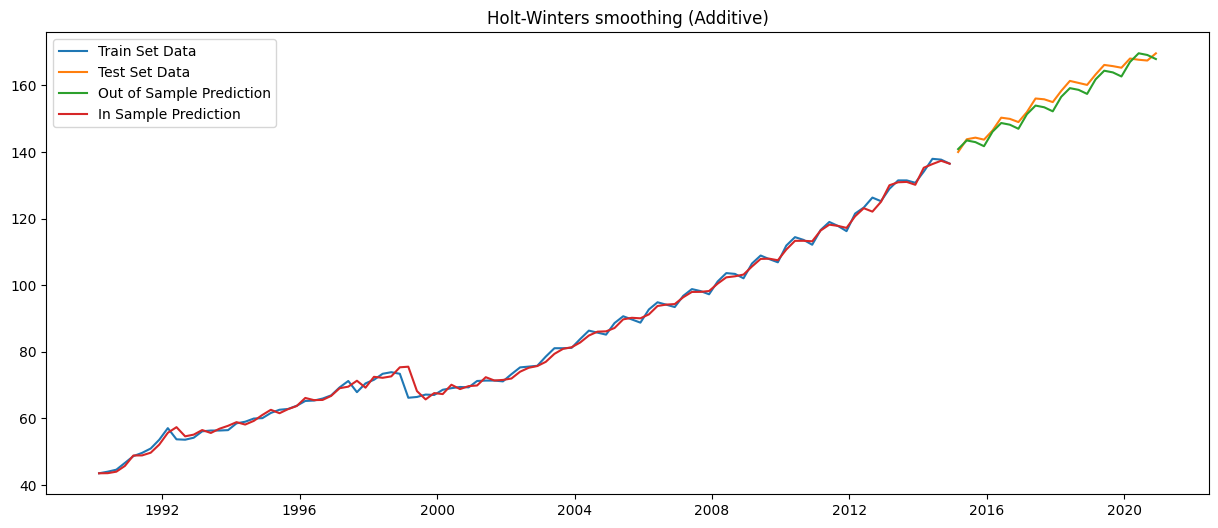

MSE for the Forecast on Test Set is 3.3505


In [40]:
y_forecast_add_df = pd.DataFrame({'time': cpi_test.index, 'CPI': y_forecast_add})
y_forecast_add_df.set_index("time", inplace = True)
# Plot forecast and test values
plt.figure(figsize=(15,6))
plt.plot(cpi_train, label='Train Set Data')
plt.plot(cpi_test, label='Test Set Data')
plt.plot(y_forecast_add_df, label='Out of Sample Prediction')
plt.plot(add_model_train_pred, label='In Sample Prediction') 
plt.legend(loc = "upper left")
plt.title("Holt-Winters smoothing (Additive)")
plt.show()
# Compute MSE on test set
print('MSE for the Forecast on Test Set is {:.4f}'.format(calculate_mse(y_forecast_add, cpi_test)))

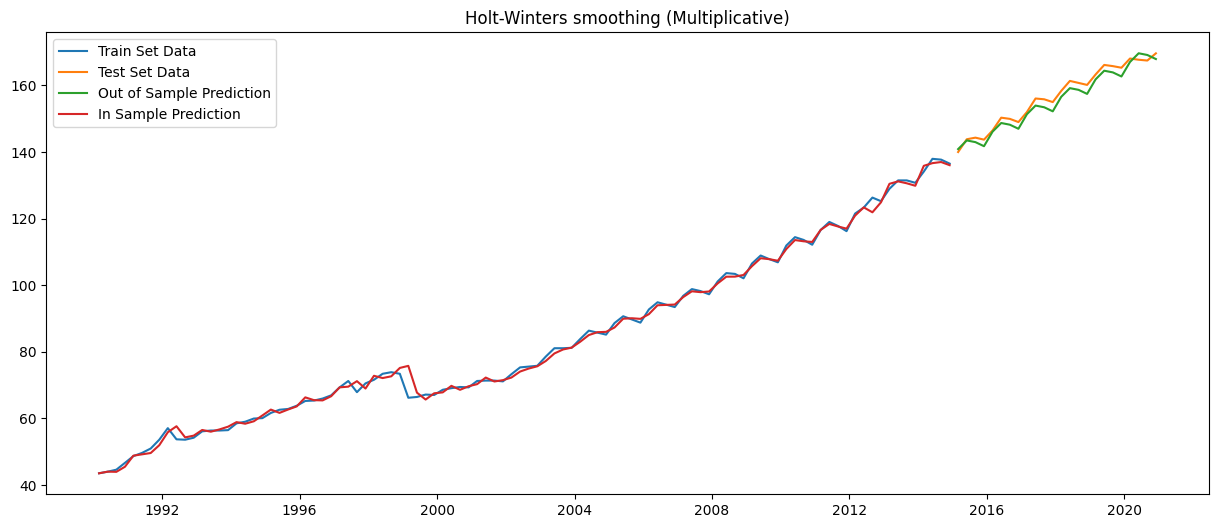

MSE for the Forecast on Test Set is 2.7973


In [41]:
y_forecast_mul_df = pd.DataFrame({'time': cpi_test.index, 'CPI': y_forecast_add})
y_forecast_mul_df.set_index("time", inplace = True)
# Plot forecast and test values
plt.figure(figsize=(15,6))
plt.plot(cpi_train, label='Train Set Data')
plt.plot(cpi_test, label='Test Set Data')
plt.plot(y_forecast_mul_df, label='Out of Sample Prediction') 
plt.plot(mul_model_train_pred, label='In Sample Prediction') 
plt.legend(loc = "upper left")
plt.title("Holt-Winters smoothing (Multiplicative)")
plt.show()
# Compute MSE on test set
print('MSE for the Forecast on Test Set is {:.4f}'.format(calculate_mse(y_forecast_mul, cpi_test)))

# **ARIMA**

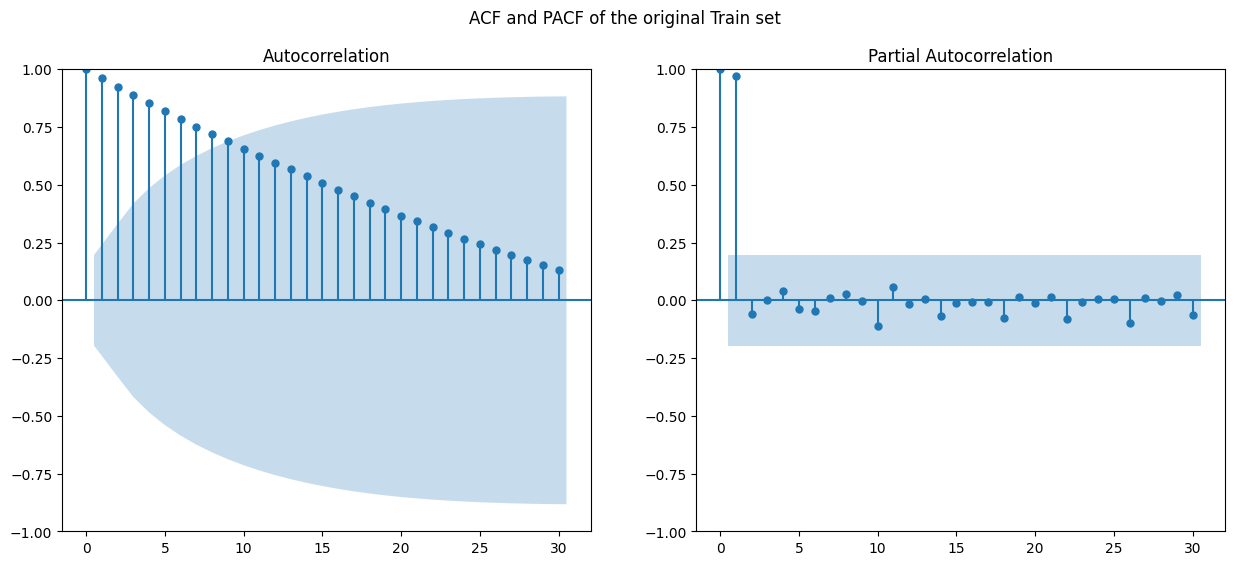

In [42]:
# Plot the sample ACF for the data. This call opens a new plot
fig, ax = plt.subplots(1, 2, sharex=True, figsize = (15, 6))
smt.graphics.tsa.plot_acf(cpi_train, lags=30, alpha = 0.05, ax = ax[0])
smt.graphics.tsa.plot_pacf(cpi_train, lags=30, alpha = 0.05, ax = ax[1])
plt.suptitle("ACF and PACF of the original Train set")
plt.show()

In [43]:
print('Results of Dickey-Fuller Test:')
test_stationarity(cpi_train)
test_result = test_stationarity(cpi_train, False)

Results of Dickey-Fuller Test:
Test Statistic                  1.544537
pvalue                          0.997681
#Lags Used                      4.000000
Number of Observations Used    95.000000
Critical Value (1%)            -3.501137
Critical Value (5%)            -2.892480
Critical Value (10%)           -2.583275
dtype: float64


In [44]:
print_outcome(test_result)

Do not reject HO at 1% level
Do not reject HO at 5% level
Do not reject HO at 10% level


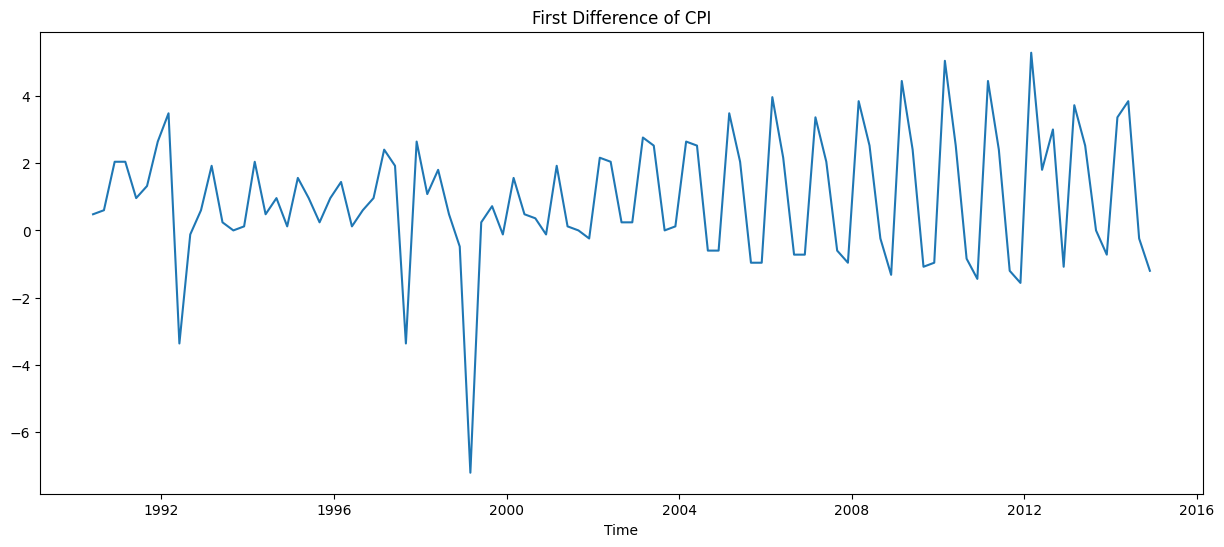

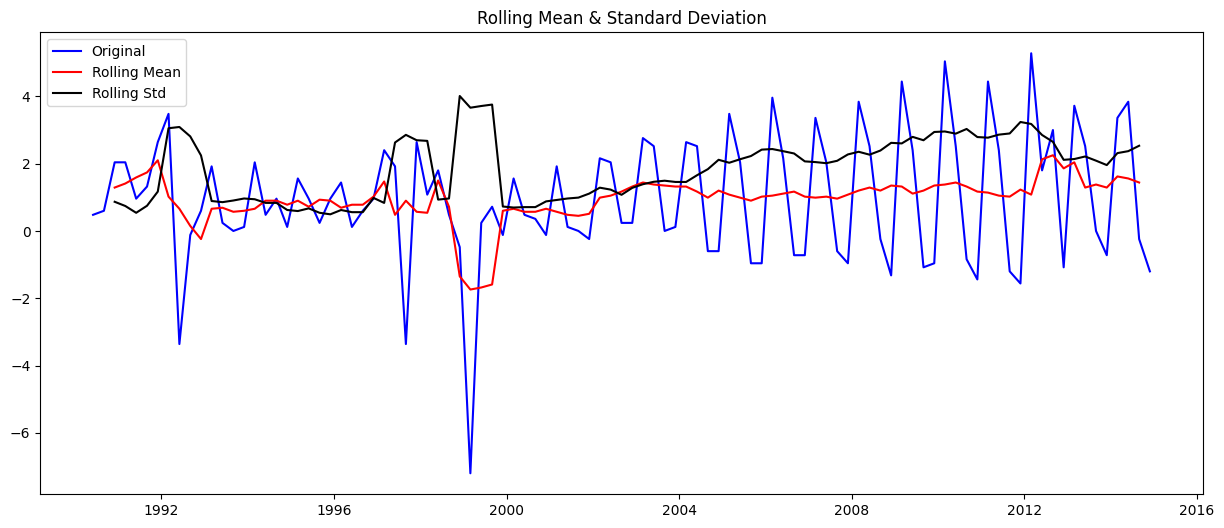

In [45]:
#check first difference of data
cpi_diff = pd.Series.diff(cpi_train)

# Discard the nan value
cpi_diff = cpi_diff.dropna()

# Plot the differenced data
plt.figure(figsize=(15,6))
plt.plot(cpi_diff)
plt.xlabel('Time')
plt.title('First Difference of CPI')
plt.show()
# Then call the plot_curve() to visualize the original, rolling mean and rolling std series
plot_curve(cpi_diff)

In [46]:
test_stationarity(cpi_diff)
first_diff_test_result = test_stationarity(cpi_diff, False)

Test Statistic                 -3.631661
pvalue                          0.005184
#Lags Used                      3.000000
Number of Observations Used    95.000000
Critical Value (1%)            -3.501137
Critical Value (5%)            -2.892480
Critical Value (10%)           -2.583275
dtype: float64


In [47]:
print_outcome(first_diff_test_result) # Thus first difference is stationary

Reject HO at 1% level
Reject HO at 5% level
Reject HO at 10% level


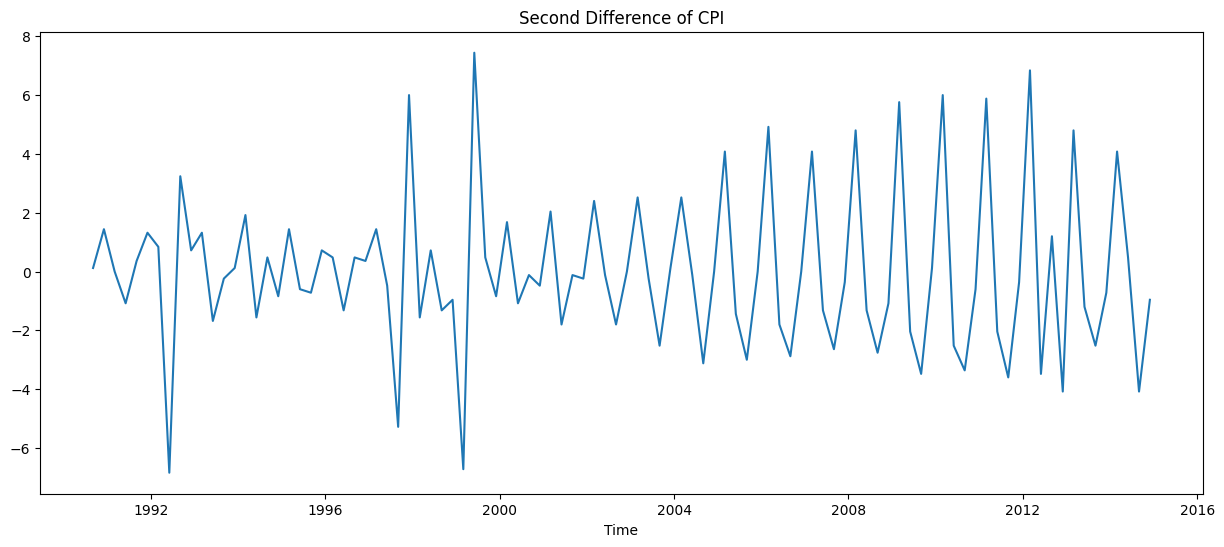

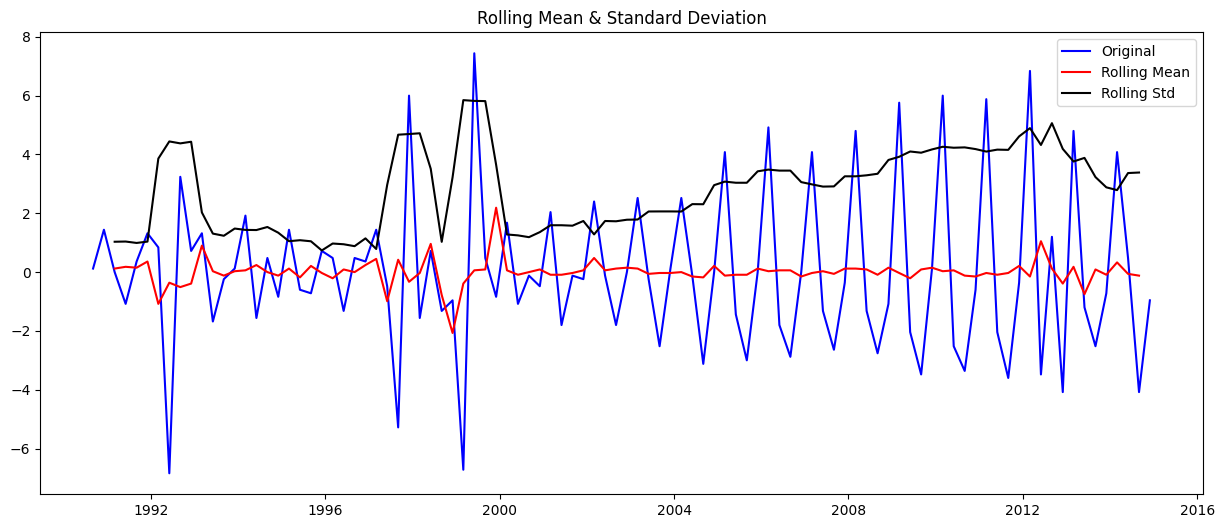

In [48]:
# second diff 
cpi_diff_diff = pd.Series.diff(cpi_diff)

# Discard the nan value
cpi_diff_diff = cpi_diff_diff.dropna()

# Plot the differenced data
plt.figure(figsize=(15,6))
plt.plot(cpi_diff_diff)
plt.xlabel('Time')
plt.title('Second Difference of CPI')
plt.show()

second_diff_result = test_stationarity(cpi_diff_diff, False)   

# Then call the plot_curve() to visualize the original, rolling mean and rolling std series
plot_curve(cpi_diff_diff)

In [49]:
test_stationarity(cpi_diff_diff, False)

Test Statistic                -7.241651e+00
pvalue                         1.877527e-10
#Lags Used                     6.000000e+00
Number of Observations Used    9.100000e+01
Critical Value (1%)           -3.504343e+00
Critical Value (5%)           -2.893866e+00
Critical Value (10%)          -2.584015e+00
dtype: float64

In [50]:
print_outcome(second_diff_result) # Second difference is also stationary

Reject HO at 1% level
Reject HO at 5% level
Reject HO at 10% level


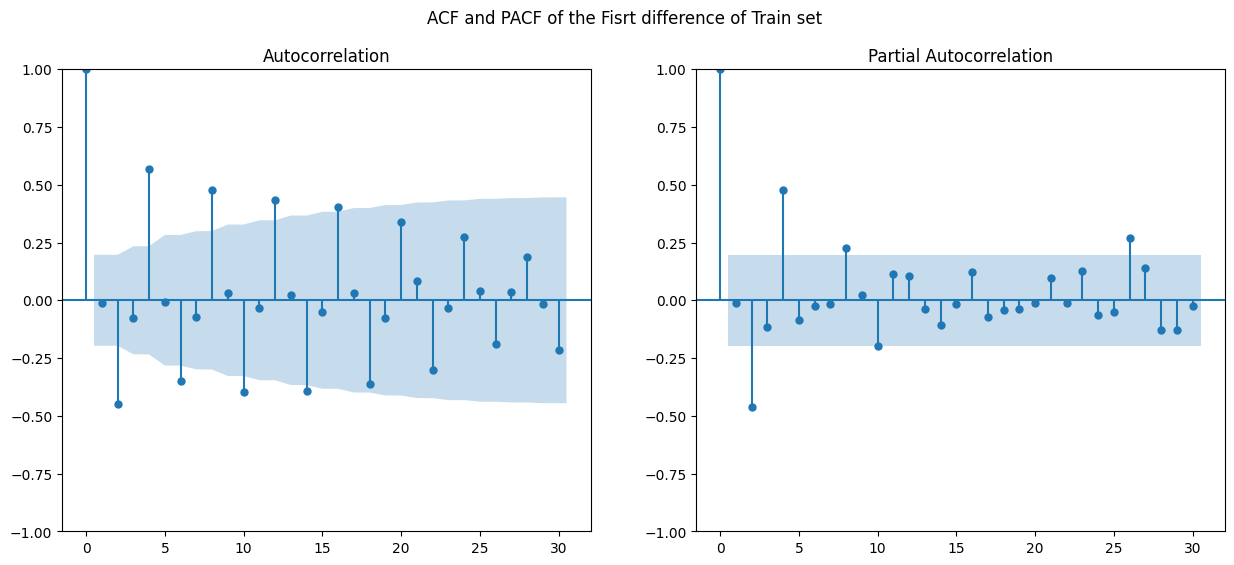

In [51]:
#Plot acf pacf for first diff
fig, ax = plt.subplots(1, 2, sharex=True, figsize = (15, 6))
smt.graphics.tsa.plot_acf(cpi_diff, lags=30, alpha = 0.05, ax = ax[0])
smt.graphics.tsa.plot_pacf(cpi_diff, lags=30, alpha = 0.05, ax = ax[1])
plt.suptitle("ACF and PACF of the Fisrt difference of Train set")
plt.show()

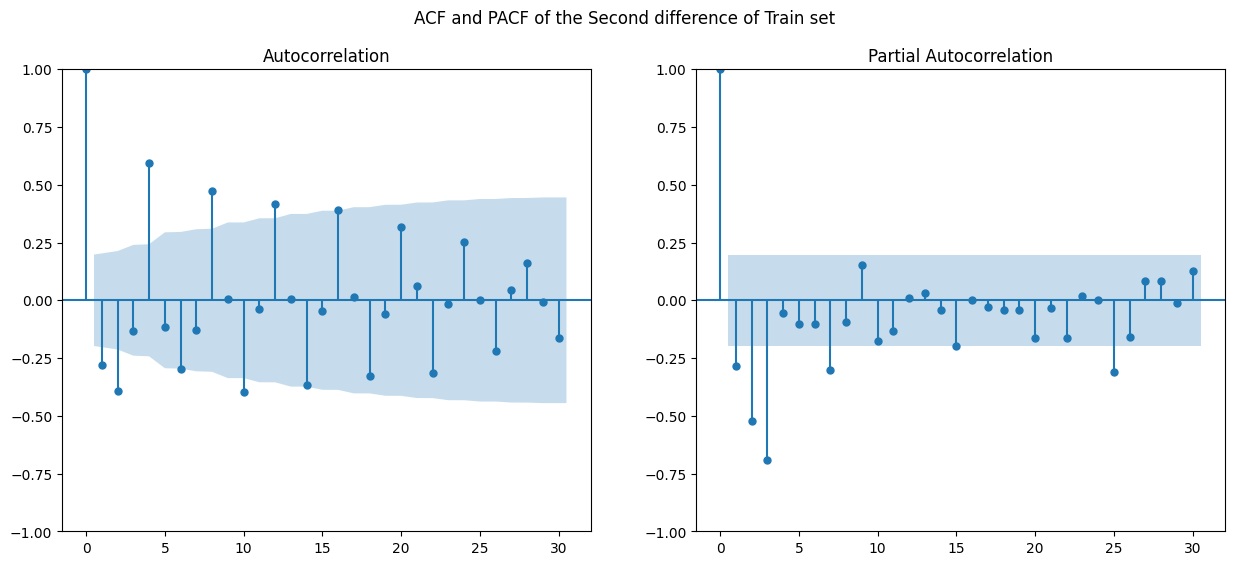

In [52]:
#Plot acf pacf for second diff
fig, ax = plt.subplots(1, 2, sharex=True, figsize = (15, 6))
smt.graphics.tsa.plot_acf(cpi_diff_diff, lags=30, alpha = 0.05, ax = ax[0])
smt.graphics.tsa.plot_pacf(cpi_diff_diff, lags=30, alpha = 0.05, ax = ax[1])
plt.suptitle("ACF and PACF of the Second difference of Train set")
plt.show()


We will stick on first difference since the first differnce rejcet the null hypothesis of Diceky Fuller Test

In [53]:
### This block takes 2 mins to run on Goolgle Colab ###
# perform grid search for ARIMA(p, 1, q)
p_ls = np.arange(0, 11)
q_ls = np.arange(0, 11)
train_mse_ls = []
test_mse_ls = []
p_q_ls = []
aic_ls = []
for p in p_ls:
  for q in q_ls:
    arima_model = ARIMA(cpi_train, order=(p, 1, q)).fit()
    train_result = arima_model.predict()
    test_result = arima_model.forecast(24)
    train_mse = calculate_mse(train_result, cpi_train)
    test_mse = calculate_mse(test_result, cpi_test)
    train_mse_ls.append(train_mse)
    test_mse_ls.append(test_mse)
    aic_ls.append(arima_model.aic)
    p_q_ls.append("({}, 1, {})".format(p, q))

In [54]:
outcome = pd.DataFrame({'Combinations': p_q_ls, 'AIC': aic_ls, 'Train MSE': train_mse_ls, 'Test MSE': test_mse_ls})
outcome

,Combinations,AIC,Train MSE,Test MSE
0,"(0, 1, 0)",432.349845,23.411701,487.006200
1,"(0, 1, 1)",428.709269,23.160586,497.224116
2,"(0, 1, 2)",429.908016,23.126940,490.440898
3,"(0, 1, 3)",427.654723,22.939622,496.772076
4,"(0, 1, 4)",401.408226,21.937982,407.579469
...,...,...,...,...
116,"(10, 1, 6)",382.087109,20.863769,13.918315
117,"(10, 1, 7)",383.147972,20.846508,14.708089
118,"(10, 1, 8)",386.136043,20.866549,8.372262
119,"(10, 1, 9)",387.777752,20.854500,7.598161


In [55]:
outcome.sort_values(by = 'Test MSE')

,Combinations,AIC,Train MSE,Test MSE
81,"(7, 1, 4)",380.098906,21.014172,3.450469
50,"(4, 1, 6)",375.505554,20.961347,4.430772
92,"(8, 1, 4)",380.224535,20.978903,4.864682
103,"(9, 1, 4)",382.574122,20.988601,5.268942
93,"(8, 1, 5)",378.844512,20.897129,5.388480
...,...,...,...,...
13,"(1, 1, 2)",431.845328,23.124157,490.876059
23,"(2, 1, 1)",434.244168,23.227395,493.775868
3,"(0, 1, 3)",427.654723,22.939622,496.772076
1,"(0, 1, 1)",428.709269,23.160586,497.224116


In [56]:
outcome.sort_values(by = 'AIC')

,Combinations,AIC,Train MSE,Test MSE
60,"(5, 1, 5)",373.749308,20.934066,11.543465
48,"(4, 1, 4)",373.964963,21.012365,5.861936
36,"(3, 1, 3)",375.342010,21.130282,8.938259
71,"(6, 1, 5)",375.402236,20.931711,9.631747
50,"(4, 1, 6)",375.505554,20.961347,4.430772
...,...,...,...,...
2,"(0, 1, 2)",429.908016,23.126940,490.440898
11,"(1, 1, 0)",430.770771,23.251239,498.256814
13,"(1, 1, 2)",431.845328,23.124157,490.876059
0,"(0, 1, 0)",432.349845,23.411701,487.006200


In [57]:
outcome.sort_values(by = 'Train MSE')

,Combinations,AIC,Train MSE,Test MSE
117,"(10, 1, 7)",383.147972,20.846508,14.708089
109,"(9, 1, 10)",387.681126,20.849491,10.172045
108,"(9, 1, 9)",385.639510,20.849575,6.989188
119,"(10, 1, 9)",387.777752,20.854500,7.598161
97,"(8, 1, 9)",383.915722,20.857682,8.039387
...,...,...,...,...
2,"(0, 1, 2)",429.908016,23.126940,490.440898
1,"(0, 1, 1)",428.709269,23.160586,497.224116
23,"(2, 1, 1)",434.244168,23.227395,493.775868
11,"(1, 1, 0)",430.770771,23.251239,498.256814


In [58]:
#Best combination is ARIMA(7, 1, 4) with lowest test MSE = 3.450469
#outcome.to_csv("ARIMA.csv")  # store the outcome

In [59]:
arima_model = ARIMA(cpi_train, order=(7, 1, 4)).fit()
train_result = arima_model.predict(start = cpi_train.index[0], end = cpi_train.index[-1])
test_result = arima_model.forecast(24)

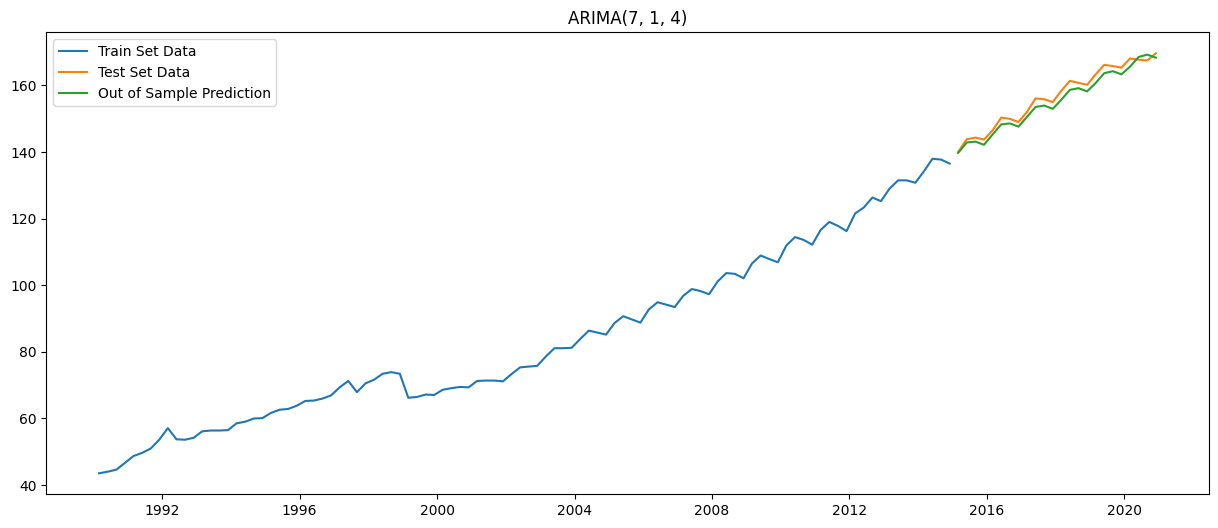

MSE for the Forecast on Test Set is 3.4505


In [60]:
test_result_df = pd.DataFrame({'time': cpi_test.index, 'CPI': test_result})
test_result_df.set_index("time", inplace = True)
train_result_df = pd.DataFrame({'time': cpi_train.index, 'CPI': train_result})
train_result_df.set_index("time", inplace = True)
# Plot forecast and test values
plt.figure(figsize=(15,6))
plt.plot(cpi_train, label='Train Set Data')
plt.plot(cpi_test, label='Test Set Data')
plt.plot(test_result_df, label='Out of Sample Prediction')
#plt.plot(train_result_df, label='In Sample Prediction')
plt.legend(loc = "upper left")
plt.title("ARIMA(7, 1, 4)")
plt.show()
# Compute MSE on test set
print('MSE for the Forecast on Test Set is {:.4f}'.format(calculate_mse(test_result, cpi_test)))

# **Seasonal ARIMA**

In [61]:
# 2mins runtime
p_ls = np.arange(0, 4)
q_ls = np.arange(0, 11)
P_ls = np.arange(0, 3)
D_ls = np.arange(0, 2)
train_mse_ls = []
test_mse_ls = []
aic_ls = []
p_q_P_Q_ls = []

m = 4
for p in p_ls:
  for q in q_ls:
    for P in P_ls:
      for D in D_ls:
        sarima_model = SARIMAX(cpi_train, 
                              order = (p,1,q),                # Non-seasonal component
                              seasonal_order = (P,D,0,m),     # Seasonal component
                              trend = 'c',                    # Intercept
                              enforce_stationarity = False,
                              enforce_invertibility = False).fit()
        train_result = sarima_model.predict()
        test_result = sarima_model.forecast(24)
        train_mse = calculate_mse(train_result, cpi_train)
        test_mse = calculate_mse(test_result, cpi_test)
        train_mse_ls.append(train_mse)
        test_mse_ls.append(test_mse)
        aic_ls.append(sarima_model.aic)
        p_q_P_Q_ls.append("({},1,{})({},{},0)".format(p, q, P, D))

In [62]:
sarima_outcome = pd.DataFrame({'Combinations': p_q_P_Q_ls, 'AIC': aic_ls, 'Train MSE': train_mse_ls, 'Test MSE': test_mse_ls})
sarima_outcome

,Combinations,AIC,Train MSE,Test MSE
0,"(0,1,0)(0,0,0)",409.667525,22.538086,77.635613
1,"(0,1,0)(0,1,0)",376.107618,29.141047,2.596443
2,"(0,1,0)(1,0,0)",361.453189,22.612306,39.781436
3,"(0,1,0)(1,1,0)",350.572397,25.713075,2.289426
4,"(0,1,0)(2,0,0)",343.768140,21.839768,30.878942
...,...,...,...,...
259,"(3,1,10)(0,1,0)",319.567005,29.772228,10.920695
260,"(3,1,10)(1,0,0)",333.531003,27.230277,36.757962
261,"(3,1,10)(1,1,0)",321.948401,29.471002,11.103797
262,"(3,1,10)(2,0,0)",332.599498,26.353026,37.051992


In [63]:
sarima_outcome.sort_values(by = 'Test MSE')

,Combinations,AIC,Train MSE,Test MSE
15,"(0,1,2)(1,1,0)",353.399575,25.741201,1.940069
199,"(3,1,0)(0,1,0)",374.423076,29.114011,2.069662
7,"(0,1,1)(0,1,0)",374.757097,29.130072,2.118733
21,"(0,1,3)(1,1,0)",355.056861,25.721993,2.203797
3,"(0,1,0)(1,1,0)",350.572397,25.713075,2.289426
...,...,...,...,...
0,"(0,1,0)(0,0,0)",409.667525,22.538086,77.635613
84,"(1,1,3)(0,0,0)",381.379667,23.485915,78.249776
42,"(0,1,7)(0,0,0)",359.568079,21.363102,78.923717
72,"(1,1,1)(0,0,0)",409.103497,22.923115,78.999843


In [64]:
sarima_outcome.sort_values(by = 'AIC')

,Combinations,AIC,Train MSE,Test MSE
215,"(3,1,2)(2,1,0)",316.557673,30.408077,20.501043
61,"(0,1,10)(0,1,0)",317.121049,28.337012,8.828344
193,"(2,1,10)(0,1,0)",317.733282,32.418691,7.560548
227,"(3,1,4)(2,1,0)",317.922520,29.198753,19.624909
127,"(1,1,10)(0,1,0)",318.079345,28.604118,8.476380
...,...,...,...,...
78,"(1,1,2)(0,0,0)",397.795796,22.158845,69.786922
6,"(0,1,1)(0,0,0)",408.316381,22.531697,71.391785
72,"(1,1,1)(0,0,0)",409.103497,22.923115,78.999843
0,"(0,1,0)(0,0,0)",409.667525,22.538086,77.635613


In [65]:
sarima_outcome.sort_values(by = 'Train MSE')

,Combinations,AIC,Train MSE,Test MSE
126,"(1,1,10)(0,0,0)",342.054869,21.102657,58.650267
60,"(0,1,10)(0,0,0)",340.055761,21.104488,58.761726
54,"(0,1,9)(0,0,0)",342.159836,21.124818,54.035486
48,"(0,1,8)(0,0,0)",348.355476,21.249886,61.679145
100,"(1,1,5)(2,0,0)",339.539704,21.282207,31.528857
...,...,...,...,...
177,"(2,1,7)(1,1,0)",326.301514,34.091002,7.175777
243,"(3,1,7)(1,1,0)",328.249407,34.218289,9.048565
179,"(2,1,7)(2,1,0)",320.228807,34.652398,10.968686
175,"(2,1,7)(0,1,0)",325.634825,34.656831,4.060093


In [66]:
#sarima_outcome.to_csv("SARIMA.csv") # store SARIMA tuning outcome

In [67]:
#Best combination for SARIMA model is (0,1,2)(1,1,0) m = 4 based on the test MSE = 1.940069
sarima_model = SARIMAX(cpi_train, 
                       order = (0,1,2),                # Non-seasonal component
                       seasonal_order = (1,1,0,4),     # Seasonal component
                       trend = 'c',                    # Intercept
                       enforce_stationarity = False,
                       enforce_invertibility = False).fit()
test_result = sarima_model.forecast(24)

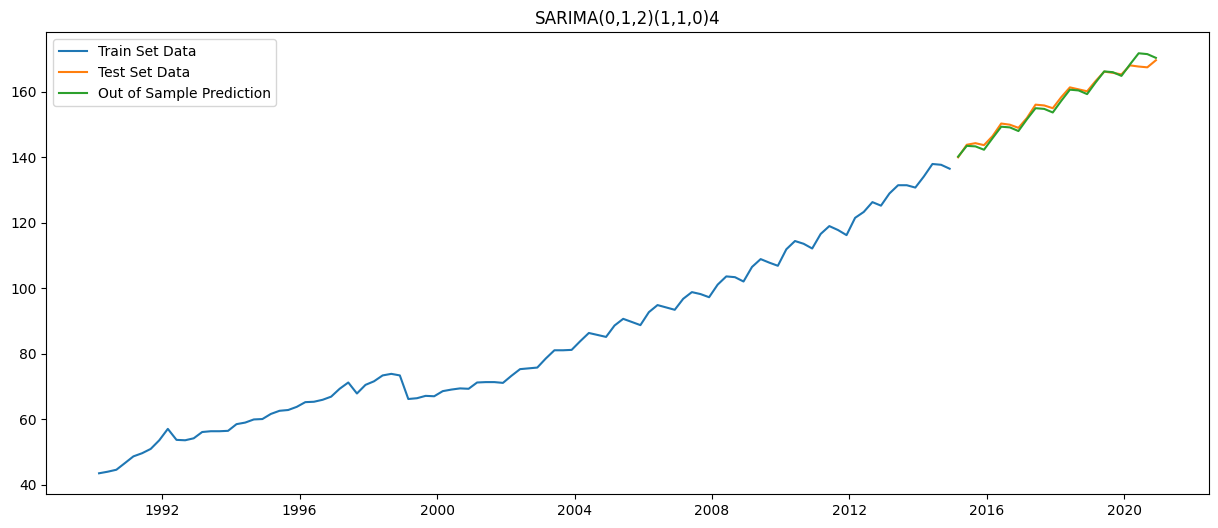

MSE for the Forecast on Test Set is 1.9401


In [68]:
test_result_df = pd.DataFrame({'time': cpi_test.index, 'CPI': test_result})
test_result_df.set_index("time", inplace = True)
# Plot forecast and test values
plt.figure(figsize=(15,6))
plt.plot(cpi_train, label='Train Set Data')
plt.plot(cpi_test, label='Test Set Data')
plt.plot(test_result_df, label='Out of Sample Prediction') 
plt.legend(loc = "upper left")
plt.title("SARIMA(0,1,2)(1,1,0)4")
plt.show()
# Compute MSE on test set
print('MSE for the Forecast on Test Set is {:.4f}'.format(calculate_mse(test_result, cpi_test)))

# **Feed Forward Neural Network**

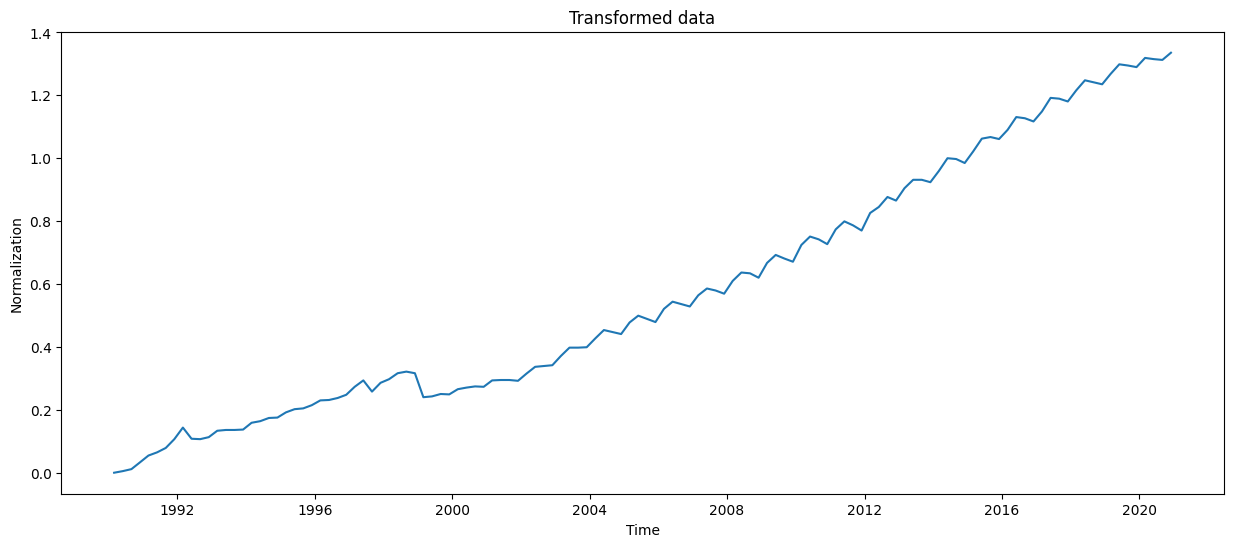

In [69]:
# Time window to define the number of features in each row
train_data = train_data.values
train_data = train_data.astype('float')

time_window = 4 #seasonal component

# Define a scaler object
scaler = MinMaxScaler(feature_range=(0, 1))

# Compute in-sample and out-of-sample size
train_size = int((len(train_data)-time_window) * 0.8)
test_size = len(train_data) - train_size-time_window

# Fitting the scaler
fitted_transformer = scaler.fit(train_data[:train_size+time_window])

# Transforming using trained scaler
cpi_scaled = fitted_transformer.transform(train_data)

# Plot the scaled data
plt.figure(figsize=(15,6))
plt.plot(cpi_train_full.index,cpi_scaled)
plt.xlabel('Time')
plt.ylabel('Normalization')
plt.title('Transformed data')
plt.show()

In [70]:
# Pre-allocation
Xall, Yall = [], []
Xall_not_scaled, Yall_not_scaled = [], []

# Use each rolling window as a row in the data matrix 
for i in range(time_window, len(cpi_scaled)):
    Xall.append(cpi_scaled[i-time_window:i, 0]) # Access the accuracy
    Xall_not_scaled.append(train_data[i-time_window:i, 0]) # Training NN
    Yall.append(cpi_scaled[i, 0])
    Yall_not_scaled.append(train_data[i, 0])

# Convert them from list to numpy array
Xall = np.array(Xall)
Yall = np.array(Yall)
Xall_not_scaled = np.array(Xall_not_scaled)
Yall_not_scaled = np.array(Yall_not_scaled)

# Training data
Xtrain = Xall[:train_size, :]
Ytrain = Yall[:train_size]

# Test data
Xtest = Xall[-test_size:, :]
Ytest = Yall[-test_size:]

In [71]:
# define model for grid search
def ffnn_model(n_hidden_layers = 1, num_of_neurons = 10, activation_function = 'relu'):
  model = Sequential()
  if n_hidden_layers == 1:
    model.add(Dense(num_of_neurons, input_dim = 4, activation=activation_function)) #input layer to the first hidden layer
    model.add(Dense(1))
  else:
    model.add(Dense(num_of_neurons, input_dim = 4, activation=activation_function))
    for layers in range(n_hidden_layers - 1):
      model.add(Dense(num_of_neurons, input_dim = num_of_neurons, activation=activation_function))
    model.add(Dense(1))
  model.compile(loss='mean_squared_error', optimizer='adam')
  return model

In [72]:
#for only 1 hidden layers, find the optimal solution for num of neurons
num_neuron = [4, 6, 8, 10, 12, 14, 16, 18, 20]
train_mse_ls = []
test_mse_ls = []
comb_ls = []

for num_n in num_neuron:
    print("Number of neurons : {} Training...".format(num_n))
    tf.keras.utils.set_random_seed(1)
    model1 = ffnn_model(n_hidden_layers = 1, num_of_neurons = num_n, activation_function = 'relu')

    model1.fit(Xtrain, Ytrain, epochs = 300, batch_size=20, verbose=0)
    dynamic_prediction = np.copy(cpi_scaled[:len(cpi_scaled) - test_size])

    for i in range(len(cpi_scaled) - test_size, len(cpi_scaled)):
      last_feature = np.reshape(dynamic_prediction[i-time_window:i], (1,time_window))
      next_pred = model1.predict(last_feature, verbose = 0)
      dynamic_prediction = np.append(dynamic_prediction, next_pred)

    dynamic_prediction = dynamic_prediction.reshape(-1,1)
    dynamic_prediction = scaler.inverse_transform(dynamic_prediction)

    train_pred = scaler.inverse_transform(model1.predict(Xtrain, verbose = 0))[:,0]
    train_mse = mean_squared_error(train_pred, Yall_not_scaled[:train_size])
    train_mse_ls.append(train_mse)
    test_mse = mean_squared_error(Yall_not_scaled[-test_size:], dynamic_prediction[-test_size:])
    test_mse_ls.append(test_mse)
    comb_ls.append("{}".format(num_n))
    print('Done!')

Number of neurons : 4 Training...
Done!
Number of neurons : 6 Training...
Done!
Number of neurons : 8 Training...
Done!
Number of neurons : 10 Training...
Done!
Number of neurons : 12 Training...
Done!
Number of neurons : 14 Training...
Done!
Number of neurons : 16 Training...
Done!
Number of neurons : 18 Training...
Done!
Number of neurons : 20 Training...
Done!


In [73]:
ffnn_outcome = pd.DataFrame({'Number of neurons': comb_ls,  'Train MSE': train_mse_ls, 'Test MSE': test_mse_ls})
ffnn_outcome

,Number of neurons,Train MSE,Test MSE
0,4,3.849777,90.892801
1,6,3.534343,29.667246
2,8,3.232110,53.498711
3,10,4.438027,19.830292
4,12,3.594169,4.451891
5,14,3.986821,7.203417
6,16,4.145043,5.738932
7,18,4.854703,17.143984
8,20,4.123649,40.864701


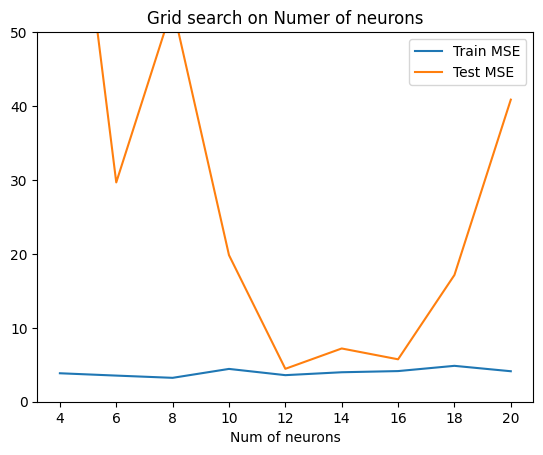

In [74]:
plt.plot(train_mse_ls,label = 'Train MSE')
plt.plot(test_mse_ls,label = 'Test MSE')
plt.xticks(range(len(comb_ls)), comb_ls)
plt.xlabel("Num of neurons")
plt.title("Grid search on Numer of neurons")
plt.ylim(0, 50)
plt.legend()
plt.show()

The optimal value for number of neurons is 12.

In [75]:
#assume hidden layer 1 and hidden layer 2 have same number of neurons (rectangle shape)
n_hidden_layers = [1, 2]
train_mse_ls = []
test_mse_ls = []
comb_ls = []

for num_h in n_hidden_layers:
    print("Number of Hidden layers: {} Training...".format(num_h))
    tf.keras.utils.set_random_seed(1)
    model1 = ffnn_model(n_hidden_layers = num_h, num_of_neurons = 12, activation_function = 'relu')

    model1.fit(Xtrain, Ytrain, epochs = 300, batch_size=20, verbose=0)
    dynamic_prediction = np.copy(cpi_scaled[:len(cpi_scaled) - test_size])

    for i in range(len(cpi_scaled) - test_size, len(cpi_scaled)):
      last_feature = np.reshape(dynamic_prediction[i-time_window:i], (1,time_window))
      next_pred = model1.predict(last_feature, verbose = 0)
      dynamic_prediction = np.append(dynamic_prediction, next_pred)

    dynamic_prediction = dynamic_prediction.reshape(-1,1)
    dynamic_prediction = scaler.inverse_transform(dynamic_prediction)

    train_pred = scaler.inverse_transform(model1.predict(Xtrain, verbose = 0))[:,0]
    train_mse = mean_squared_error(train_pred, Yall_not_scaled[:train_size])
    train_mse_ls.append(train_mse)
    test_mse = mean_squared_error(Yall_not_scaled[-test_size:], dynamic_prediction[-test_size:])
    test_mse_ls.append(test_mse)
    comb_ls.append("{}".format(num_h))
    print('Done!')

Number of Hidden layers: 1 Training...
Done!
Number of Hidden layers: 2 Training...
Done!


In [76]:
ffnn_outcome = pd.DataFrame({'Number of hidden layers': comb_ls,  'Train MSE': train_mse_ls, 'Test MSE': test_mse_ls})
ffnn_outcome

,Number of hidden layers,Train MSE,Test MSE
0,1,3.594169,4.451891
1,2,3.476784,194.767083


1 hidden layer is preferred since it has much lower MSE on test set.

In [77]:
# Find optimal solution for number of epochs
n_epochs = [100, 200, 300, 500, 1000]
train_mse_ls = []
test_mse_ls = []
comb_ls = []

for epoch in n_epochs:
    print("Number of epochs: {} Training...".format(epoch))
    tf.keras.utils.set_random_seed(1)
    model1 = ffnn_model(n_hidden_layers = 1, num_of_neurons = 12, activation_function = 'relu')

    model1.fit(Xtrain, Ytrain, epochs = epoch, batch_size=20, verbose=0)
    dynamic_prediction = np.copy(cpi_scaled[:len(cpi_scaled) - test_size])
    
    for i in range(len(cpi_scaled) - test_size, len(cpi_scaled)):
      last_feature = np.reshape(dynamic_prediction[i-time_window:i], (1,time_window))
      next_pred = model1.predict(last_feature, verbose = 0)
      dynamic_prediction = np.append(dynamic_prediction, next_pred)

    dynamic_prediction = dynamic_prediction.reshape(-1,1)
    dynamic_prediction = scaler.inverse_transform(dynamic_prediction)

    train_pred = scaler.inverse_transform(model1.predict(Xtrain, verbose = 0))[:,0]
    train_mse = mean_squared_error(train_pred, Yall_not_scaled[:train_size])
    train_mse_ls.append(train_mse)
    test_mse = mean_squared_error(Yall_not_scaled[-test_size:], dynamic_prediction[-test_size:])
    test_mse_ls.append(test_mse)
    comb_ls.append("{}".format(epoch))
    print('Done!')

Number of epochs: 100 Training...
Done!
Number of epochs: 200 Training...
Done!
Number of epochs: 300 Training...
Done!
Number of epochs: 500 Training...
Done!
Number of epochs: 1000 Training...
Done!


In [78]:
ffnn_outcome = pd.DataFrame({'Number of Epochs': comb_ls,  'Train MSE': train_mse_ls, 'Test MSE': test_mse_ls})
ffnn_outcome

,Number of Epochs,Train MSE,Test MSE
0,100,4.008789,60.310072
1,200,3.810811,27.803563
2,300,3.594169,4.451891
3,500,3.179945,15.465769
4,1000,2.477559,11.389627


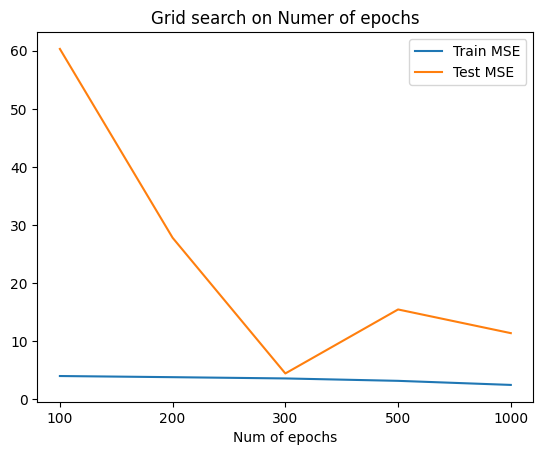

In [79]:
plt.plot(train_mse_ls,label = 'Train MSE')
plt.plot(test_mse_ls,label = 'Test MSE')
plt.xticks(range(len(comb_ls)), comb_ls)
plt.xlabel("Num of epochs")
plt.title("Grid search on Numer of epochs")
plt.legend()
plt.show()

In [80]:
#Grid search on batch size
n_batch_size = [1, 8, 20, 32, 64]
train_mse_ls = []
test_mse_ls = []
comb_ls = []

for batch_size in n_batch_size:
    print("Number of batch_size: {} Training...".format(batch_size))
    tf.keras.utils.set_random_seed(1)
    model1 = ffnn_model(n_hidden_layers = 1, num_of_neurons = 12, activation_function = 'relu')
    
    model1.fit(Xtrain, Ytrain, epochs = 300, batch_size=batch_size, verbose=0)
    dynamic_prediction = np.copy(cpi_scaled[:len(cpi_scaled) - test_size])

    for i in range(len(cpi_scaled) - test_size, len(cpi_scaled)):
      last_feature = np.reshape(dynamic_prediction[i-time_window:i], (1,time_window))
      next_pred = model1.predict(last_feature, verbose = 0)
      dynamic_prediction = np.append(dynamic_prediction, next_pred)

    dynamic_prediction = dynamic_prediction.reshape(-1,1)
    dynamic_prediction = scaler.inverse_transform(dynamic_prediction)

    train_pred = scaler.inverse_transform(model1.predict(Xtrain, verbose = 0))[:,0]
    train_mse = mean_squared_error(train_pred, Yall_not_scaled[:train_size])
    train_mse_ls.append(train_mse)
    test_mse = mean_squared_error(Yall_not_scaled[-test_size:], dynamic_prediction[-test_size:])
    test_mse_ls.append(test_mse)
    comb_ls.append("{}".format(batch_size))
    print('Done!')

Number of batch_size: 1 Training...
Done!
Number of batch_size: 8 Training...
Done!
Number of batch_size: 20 Training...
Done!
Number of batch_size: 32 Training...
Done!
Number of batch_size: 64 Training...
Done!


In [81]:
ffnn_outcome = pd.DataFrame({'Number of batch size': comb_ls,  'Train MSE': train_mse_ls, 'Test MSE': test_mse_ls})
ffnn_outcome

,Number of batch size,Train MSE,Test MSE
0,1,1.884795,64.538250
1,8,3.048010,8.985982
2,20,3.594169,4.451891
3,32,3.838433,31.482105
4,64,4.202467,6.085613


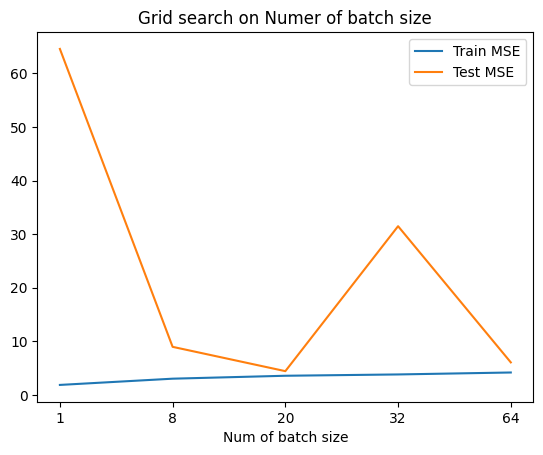

In [82]:
plt.plot(train_mse_ls,label = 'Train MSE')
plt.plot(test_mse_ls,label = 'Test MSE')
plt.xticks(range(len(comb_ls)), comb_ls)
plt.xlabel("Num of batch size")
plt.title("Grid search on Numer of batch size")
plt.legend()
plt.show()

In [83]:
# fit model based on the best value of hyperparameters
tf.keras.utils.set_random_seed(1)
model1 = ffnn_model(n_hidden_layers = 1, num_of_neurons = 12, activation_function = 'relu')
model1.fit(Xtrain, Ytrain, epochs = 300, batch_size=20, verbose=0)
dynamic_prediction = np.copy(cpi_scaled[:len(cpi_scaled) - test_size])

for i in range(len(cpi_scaled) - test_size, len(cpi_scaled)):
  last_feature = np.reshape(dynamic_prediction[i-time_window:i], (1,time_window))
  next_pred = model1.predict(last_feature, verbose = 0)
  dynamic_prediction = np.append(dynamic_prediction, next_pred)

dynamic_prediction = dynamic_prediction.reshape(-1,1)
dynamic_prediction = scaler.inverse_transform(dynamic_prediction)
train_pred = scaler.inverse_transform(model1.predict(Xtrain, verbose = 0))[:,0]
train_mse = mean_squared_error(train_pred, Yall_not_scaled[:train_size])
test_mse = mean_squared_error(Yall_not_scaled[-test_size:], dynamic_prediction[-test_size:])

Dynamic Forecast MSE on original scale: 4.4519


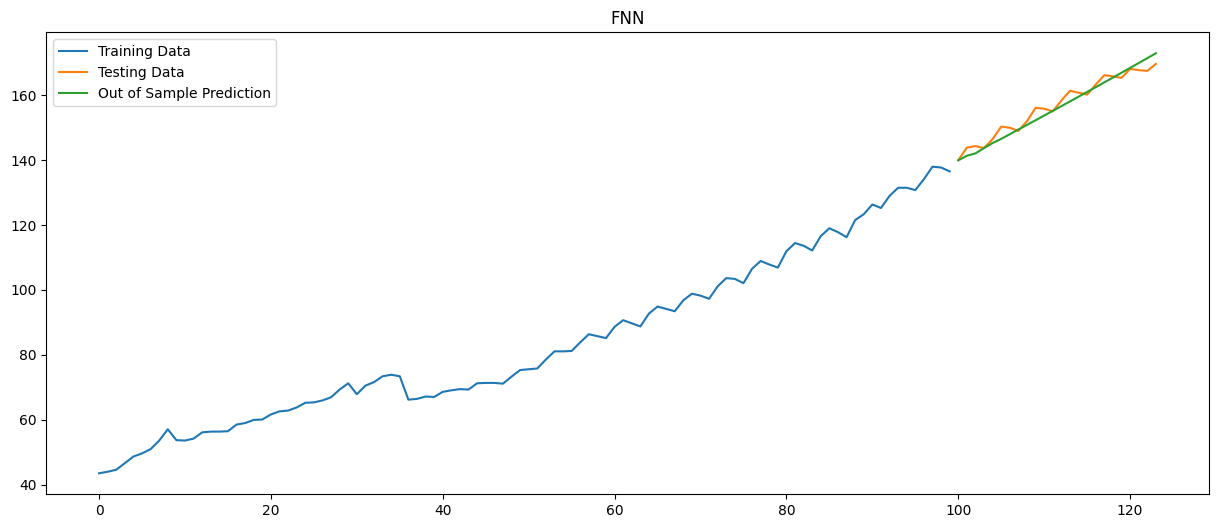

In [84]:
# Plot forecast and test values
import math
plt.figure(figsize=(15,6))
plt.plot(scaler.inverse_transform(cpi_scaled[:len(cpi_scaled) - test_size]), label='Training Data')
plt.plot(np.arange(len(cpi_scaled) - test_size, len(cpi_scaled), 1), scaler.inverse_transform(cpi_scaled[-test_size:]), label='Testing Data')
plt.plot(np.arange(len(cpi_scaled) - test_size, len(cpi_scaled), 1), dynamic_prediction[-test_size:], label='Out of Sample Prediction') 
plt.title('FNN')
plt.legend(loc = "upper left")

# Compute RMSE on original scale
testScore_dynamic = mean_squared_error(Yall_not_scaled[-test_size:], dynamic_prediction[-test_size:])
print('Dynamic Forecast MSE on original scale: {0:.4f}'.format(testScore_dynamic))

# **LSTM**

In [85]:
# For time series and LSTM layer we need to reshape into 3D array
Xtrain = np.reshape(Xtrain, (Xtrain.shape[0], time_window,1))
Xtest = np.reshape(Xtest, (Xtest.shape[0], time_window,1))

def lstm_model(num_of_neurons):
  model = Sequential()
  model.add(LSTM(units = num_of_neurons , input_shape = (time_window,1)))
  model.add(Dense(1))
  model.compile(loss='mean_squared_error', optimizer='adam')
  return model

In [86]:
#Grid search on number of neurons
n_neurons = [5, 10, 15, 20, 30, 50]
train_mse_ls = []
test_mse_ls = []
comb_ls = []

for n_neuron in n_neurons:
    print("Number of neurons: {} Training...".format(n_neuron))
    tf.keras.utils.set_random_seed(1)
    model1 = lstm_model(num_of_neurons = n_neuron)

    model1.fit(Xtrain, Ytrain, epochs = 300, batch_size=20, verbose=0)
    dynamic_prediction = np.copy(cpi_scaled[:len(cpi_scaled) - test_size])

    for i in range(len(cpi_scaled) - test_size, len(cpi_scaled)):
      last_feature = np.reshape(dynamic_prediction[i-time_window:i], (1,time_window, 1))
      next_pred = model1.predict(last_feature, verbose = 0)
      dynamic_prediction = np.append(dynamic_prediction, next_pred)

    dynamic_prediction = dynamic_prediction.reshape(-1,1)
    dynamic_prediction = scaler.inverse_transform(dynamic_prediction)

    train_pred = scaler.inverse_transform(model1.predict(Xtrain, verbose = 0))
    train_mse = mean_squared_error(train_pred, Yall_not_scaled[:train_size])
    train_mse_ls.append(train_mse)
    test_mse = mean_squared_error(Yall_not_scaled[-test_size:], dynamic_prediction[-test_size:])
    test_mse_ls.append(test_mse)
    comb_ls.append("{}".format(n_neuron))
    print('Done!')

Number of neurons: 5 Training...
Done!
Number of neurons: 10 Training...
Done!
Number of neurons: 15 Training...
Done!
Number of neurons: 20 Training...
Done!
Number of neurons: 30 Training...
Done!
Number of neurons: 50 Training...
Done!


In [87]:
lstm_outcome = pd.DataFrame({'Number of neurons': comb_ls,  'Train MSE': train_mse_ls, 'Test MSE': test_mse_ls})
lstm_outcome

,Number of neurons,Train MSE,Test MSE
0,5,3.643706,67.767762
1,10,3.950432,201.373900
2,15,3.760343,44.873700
3,20,3.911443,2.881421
4,30,4.030150,1.791886
5,50,3.957519,141.174223


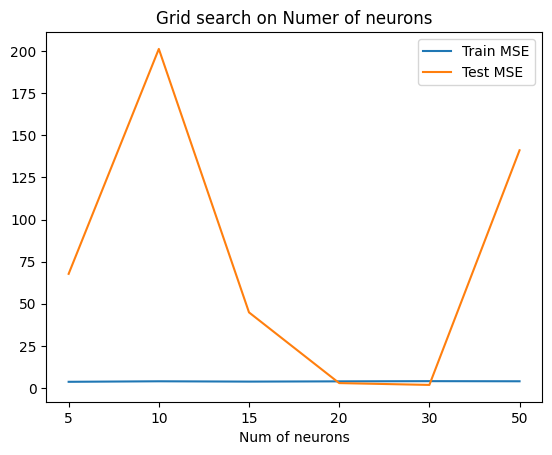

In [88]:
plt.plot(train_mse_ls,label = 'Train MSE')
plt.plot(test_mse_ls,label = 'Test MSE')
plt.xticks(range(len(comb_ls)), comb_ls)
plt.xlabel("Num of neurons")
plt.title("Grid search on Numer of neurons")
plt.legend()
plt.show()

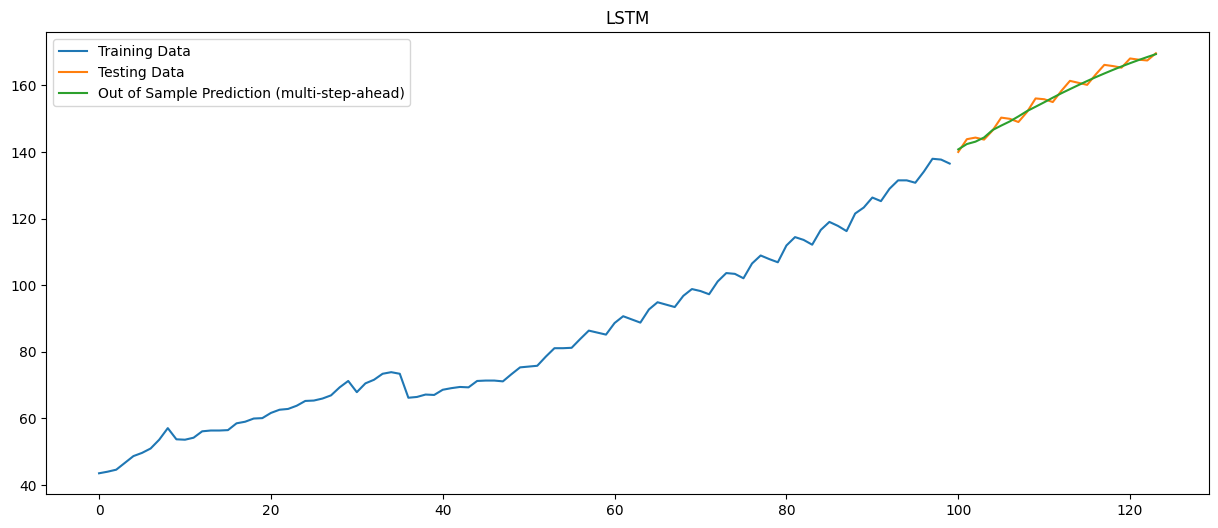

In [89]:
tf.keras.utils.set_random_seed(1)
model = lstm_model(num_of_neurons = 30)

model.fit(Xtrain, Ytrain, epochs = 300, batch_size=20, verbose=0)

dynamic_prediction = np.copy(cpi_scaled[:len(cpi_scaled) - test_size])
for i in range(len(cpi_scaled) - test_size, len(cpi_scaled)):
    last_feature = np.reshape(dynamic_prediction[i-time_window:i], (1,time_window,1))
    next_pred = model.predict(last_feature, verbose = 0)
    dynamic_prediction = np.append(dynamic_prediction, next_pred)

# Transform forecast values to original scale
dynamic_prediction = dynamic_prediction.reshape(-1,1)
dynamic_prediction_original_scale = scaler.inverse_transform(dynamic_prediction)

# Plot
test_index = np.arange(len(cpi_scaled) - test_size, len(cpi_scaled), 1)

plt.figure(figsize=(15,6))
plt.plot(scaler.inverse_transform(cpi_scaled[:len(cpi_scaled) - test_size]), label='Training Data')
plt.plot(test_index, scaler.inverse_transform(cpi_scaled[-test_size:]), label='Testing Data')
plt.plot(test_index, dynamic_prediction_original_scale[-test_size:], label='Out of Sample Prediction (multi-step-ahead)')
plt.title('LSTM')
plt.legend(loc = "upper left")
plt.show()

In [90]:
# Compute RMSE score on test data
testScore_dynamic = mean_squared_error(Yall_not_scaled[-test_size:], dynamic_prediction_original_scale[-test_size:])
print('Dynamic Forecast MSE on original scale: {0:.4f}'.format(testScore_dynamic))

Dynamic Forecast MSE on original scale: 1.7919


The LSTM model fit the Test data well with the lowest MSE, but it does not capture the seasonal trend like SARIMA model.

# **Final Forecast**

***Candiate Model 1: SARIMA(0,1,2)(1,1,0) M=4***

In [91]:
final_sarima_model = SARIMAX(cpi_train_full, 
                       order = (0,1,2),                # Non-seasonal component
                       seasonal_order = (1,1,0,4),     # Seasonal component
                       trend = 'c',                    # Intercept
                       enforce_stationarity = False,
                       enforce_invertibility = False).fit()
result = final_sarima_model.forecast(8)

In [92]:
#result.to_csv('Group_41_forecast.csv', header = ['CPI'])

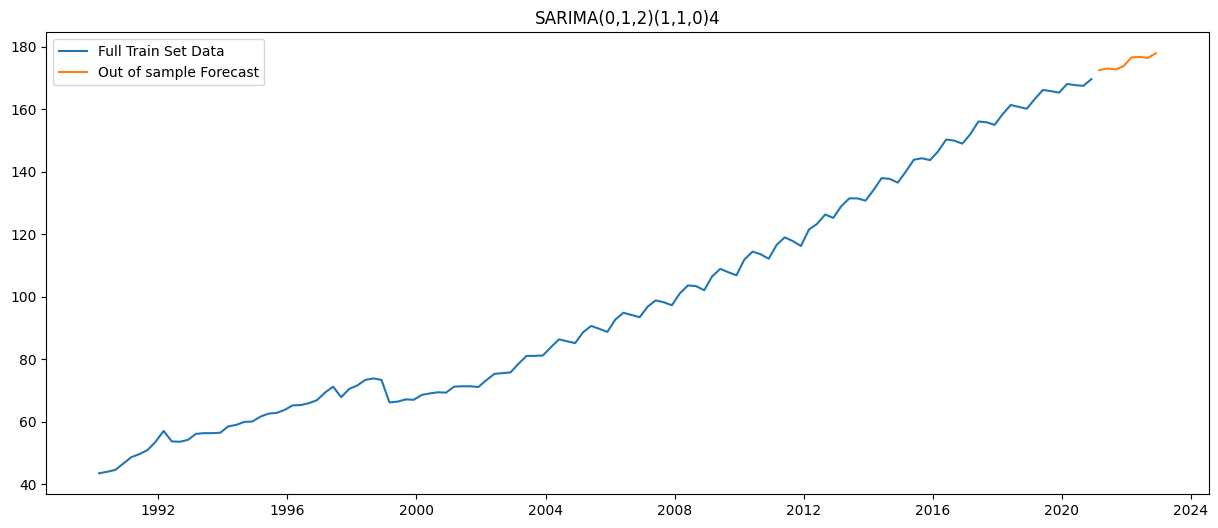

In [93]:
plt.figure(figsize=(15,6))
plt.plot(cpi_train_full, label='Full Train Set Data')
plt.plot(result, label='Out of sample Forecast')
plt.legend(loc = "upper left")
plt.title("SARIMA(0,1,2)(1,1,0)4")
plt.show()

***Candiate Model 2: LSTM model***

In [94]:
time_window = 4 #seasonal component
# Compute in-sample and out-of-sample size
fitted_transformer = scaler.fit(train_data)
# Transforming using trained scaler
cpi_full_scaled = fitted_transformer.transform(train_data)

# Pre-allocation
Xall, Yall = [], []
Xall_not_scaled, Yall_not_scaled = [], []

# Use each rolling window as a row in the data matrix 
for i in range(time_window, len(cpi_full_scaled)):
    Xall.append(cpi_full_scaled[i-time_window:i, 0]) # Access the accuracy
    Xall_not_scaled.append(train_data[i-time_window:i, 0]) # Training NN
    Yall.append(cpi_full_scaled[i, 0])
    Yall_not_scaled.append(train_data[i, 0])

# Convert them from list to numpy array
Xall = np.array(Xall)
Yall = np.array(Yall)
Xall_not_scaled = np.array(Xall_not_scaled)
Yall_not_scaled = np.array(Yall_not_scaled)

Xall = np.reshape(Xall, (Xall.shape[0], time_window,1))

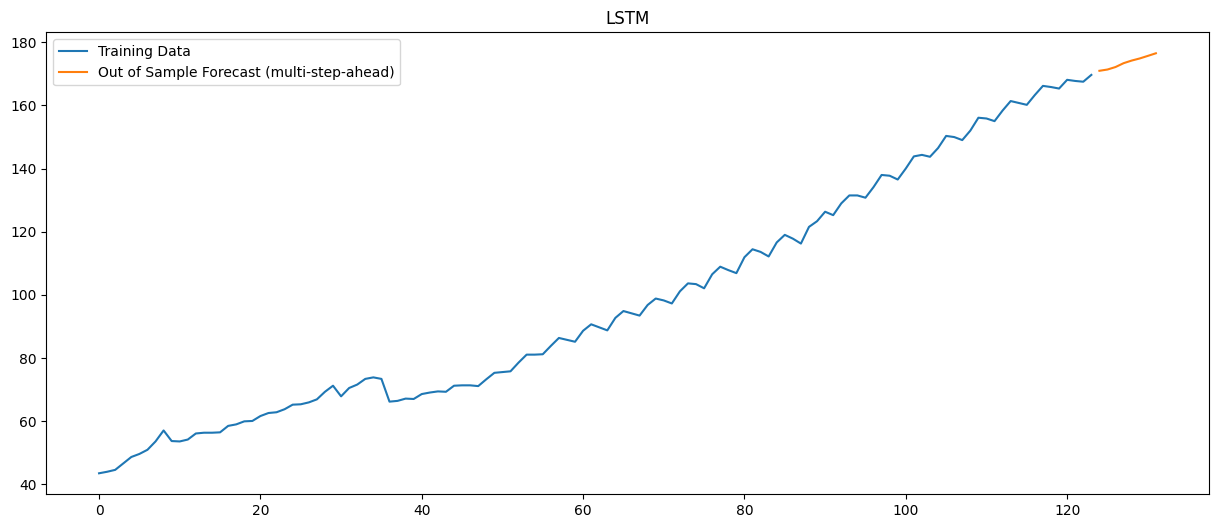

In [95]:
tf.keras.utils.set_random_seed(1)
model = lstm_model(num_of_neurons = 30)
model.fit(Xall, Yall, epochs = 300, batch_size=20, verbose=0)

dynamic_prediction = np.copy(cpi_full_scaled)
for i in range(len(cpi_full_scaled), len(cpi_full_scaled)+ 8):
    last_feature = np.reshape(dynamic_prediction[i-time_window:i], (1,time_window,1))
    next_pred = model.predict(last_feature, verbose = 0)
    dynamic_prediction = np.append(dynamic_prediction, next_pred)

# Transform forecast values to original scale
dynamic_prediction = dynamic_prediction.reshape(-1,1)
dynamic_prediction_original_scale = scaler.inverse_transform(dynamic_prediction)

# Plot
test_index = np.arange(len(cpi_full_scaled), len(cpi_scaled) + 8, 1)

plt.figure(figsize=(15,6))
plt.plot(scaler.inverse_transform(cpi_full_scaled), label='Training Data')
#plt.plot(test_index, scaler.inverse_transform(cpi_full_scaled[-test_size:]), label='Testing Data')
plt.plot(test_index, dynamic_prediction_original_scale[-8:], label='Out of Sample Forecast (multi-step-ahead)')
plt.title('LSTM')
plt.legend(loc = "upper left")
plt.show()

In [96]:
dynamic_prediction_original_scale[-8:]

array([[170.93379998],
       [171.33435381],
       [172.12818468],
       [173.34400883],
       [174.16972825],
       [174.83940277],
       [175.6492606 ],
       [176.47732543]])